# Evaluation, uncertainty and robustness

Executable scientific definitions and computed results are presented below. Data, fitted models, tables and figures are stored in the corresponding standard project directories. Earlier experiments are preserved separately in `Data/legacy/Notebooks/` and are not mixed with the current results.

In [1]:
from pathlib import Path
import sys, types, hashlib, importlib.abc, importlib.util
import nbformat
import pandas as pd
from IPython.core.magic import register_cell_magic
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Notebooks').is_dir() and (p/'Data').is_dir())
MODULE_NOTEBOOKS={'revision_data': '02_data_preprocessing_feature_engineering_and_splits.ipynb', 'revision_models': '03_baseline_models.ipynb', 'revision_sensitivity': '02_data_preprocessing_feature_engineering_and_splits.ipynb', 'revision_neural': '04_sota_models.ipynb', 'revision_evaluation': '06_final_validation_tables_figures_and_reports.ipynb', 'revision_supplemental': '06_final_validation_tables_figures_and_reports.ipynb', 'revision_provenance': '05_proposed_hybrid_model_and_ablations.ipynb', 'revision_validation': '02_data_preprocessing_feature_engineering_and_splits.ipynb', 'revision_closure': '06_final_validation_tables_figures_and_reports.ipynb', 'revision_status': '06_final_validation_tables_figures_and_reports.ipynb'}

class NotebookSourceLoader(importlib.abc.Loader):
    def create_module(self,spec):return None
    def exec_module(self,module):
        path=ROOT/'Notebooks'/MODULE_NOTEBOOKS[module.__name__]
        notebook=nbformat.read(path,4)
        cell=next(c for c in notebook.cells if c.metadata.get('research_module')==module.__name__)
        source=cell.source.split('\n',1)[1]
        module.__file__=str(path)
        module.__notebook_source_sha256__=hashlib.sha256(source.encode()).hexdigest()
        exec(compile(source,str(path)+'#'+cell.id,'exec'),module.__dict__)

class NotebookSourceFinder(importlib.abc.MetaPathFinder):
    def find_spec(self,fullname,path=None,target=None):
        if fullname in MODULE_NOTEBOOKS:
            return importlib.util.spec_from_loader(fullname,NotebookSourceLoader())
sys.meta_path=[f for f in sys.meta_path if type(f).__name__!='NotebookSourceFinder']
sys.meta_path.insert(0,NotebookSourceFinder())

@register_cell_magic
def research_module(line,source):
    """Publish the visible functions for reuse by other notebooks; no hidden helper scripts."""
    name=line.strip();digest=hashlib.sha256(source.rstrip('\n').encode()).hexdigest()
    existing=sys.modules.get(name)
    if existing is not None and existing.__notebook_source_sha256__==digest:return
    module=types.ModuleType(name);module.__file__=str(ROOT/'Notebooks'/MODULE_NOTEBOOKS[name])
    module.__notebook_source_sha256__=digest;sys.modules[name]=module
    exec(compile(source.rstrip('\n'),module.__file__,'exec'),module.__dict__)

@register_cell_magic
def legacy_snapshot(line,cell):
    """Archived analysis is preserved but is not part of the current execution."""
    return None

import revision_data as rd
artifact_path=rd.artifact_path
import matplotlib as mpl
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
mpl.rcParams.update({'figure.dpi':350,'savefig.dpi':350})
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',100)

### Evaluation — executable definitions

The functions below are the source used by this notebook and reused by the other notebooks. Defining them does not repeat model fitting.

In [2]:
%%research_module revision_evaluation
"""Prediction-registry evaluation; no manuscript/report generation."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
import json
import time
import platform
import joblib
import numpy as np
import pandas as pd
from numba import njit
from scipy.stats import hypergeom
from sklearn.metrics import roc_auc_score
from threadpoolctl import threadpool_limits,threadpool_info
from revision_data import ROOT,V,KEYS,FEATURES,protocol,digest,save_json,table,EventReplay,fit_representation
from revision_models import metrics,predict,calibrate,hierarchy_apply,prediction_frame

@njit
def bootstrap_metrics(y,p,w,order,extended=True):
    n=len(y);mass=w.sum();pos=(w*y).sum();neg=mass-pos
    out=np.full(8,np.nan)
    if mass<=0 or pos<=0 or neg<=0:return out
    auc=0.;cneg=0.;ll=0.;brier=0.;eb=np.zeros(15)
    i=0
    while i<n:
        j=i;gp=0.;gn=0.;pv=p[order[i]]
        while j<n and p[order[j]]==pv:
            ix=order[j];gp+=w[ix]*y[ix];gn+=w[ix]*(1-y[ix]);j+=1
        auc+=gp*(cneg+.5*gn);cneg+=gn;i=j
    for i in range(n):
        ll+=w[i]*(-y[i]*np.log(p[i])-(1-y[i])*np.log1p(-p[i]));brier+=w[i]*(y[i]-p[i])**2
        b=min(int(p[i]*15),14);eb[b]+=w[i]*(y[i]-p[i])
    out[0]=auc/(pos*neg);out[1]=ll/mass;out[2]=brier/mass;out[3]=np.abs(eb).sum()/mass
    if not extended:return out
    tp=fp=ap=0.;i=n-1
    while i>=0:
        j=i;gp=gn=0.;pv=p[order[i]]
        while j>=0 and p[order[j]]==pv:
            ix=order[j];gp+=w[ix]*y[ix];gn+=w[ix]*(1-y[ix]);j-=1
        tp+=gp;fp+=gn
        if tp+fp>0:ap+=gp/pos*tp/(tp+fp)
        i=j
    out[4]=ap
    tp=fp=ap=0.;i=0
    while i<n:
        j=i;gp=gn=0.;pv=p[order[i]]
        while j<n and p[order[j]]==pv:
            ix=order[j];gp+=w[ix]*(1-y[ix]);gn+=w[ix]*y[ix];j+=1
        tp+=gp;fp+=gn
        if tp+fp>0:ap+=gp/neg*tp/(tp+fp)
        i=j
    out[5]=ap
    x=np.log(p/(1-p));a=0.;b=1.;converged=False
    for iteration in range(40):
        g0=g1=h00=h01=h11=0.
        for j in range(n):
            z=min(max(a+b*x[j],-40),40);r=1/(1+np.exp(-z));grad=w[j]*(y[j]-r);curv=w[j]*r*(1-r)
            g0+=grad;g1+=grad*x[j];h00+=curv;h01+=curv*x[j];h11+=curv*x[j]*x[j]
        det=h00*h11-h01*h01
        if det<1e-12:break
        da=(h11*g0-h01*g1)/det;db=(h00*g1-h01*g0)/det
        scale=max(1.,abs(da)/2,abs(db)/2);a+=da/scale;b+=db/scale
        if max(abs(da),abs(db))<1e-7:converged=True;break
    if converged:out[6]=a;out[7]=b
    return out

METRIC_NAMES=['ROC_AUC','Log_Loss','Brier','ECE15','AP_correct','AP_incorrect','Calibration_Intercept','Calibration_Slope']

def paired_bootstrap(frame,pa,pb,method='student',B=None,seed=20260713,extended=True,name='primary',base_weights=None):
    B=protocol()['bootstrap_B'] if B is None else B
    y=frame.y.to_numpy(float);pa=np.clip(np.asarray(pa,float),1e-6,1-1e-6);pb=np.clip(np.asarray(pb,float),1e-6,1-1e-6)
    ui,ul=pd.factorize(frame.UserId,sort=True);qi,ql=pd.factorize(frame.QuestionId,sort=True);rng=np.random.default_rng(seed)
    oa=np.argsort(pa);ob=np.argsort(pb);draws=np.full((B,8),np.nan);a_draws=np.full_like(draws,np.nan);b_draws=np.full_like(draws,np.nan)
    for b in range(B):
        if method=='student':w=rng.multinomial(len(ul),np.ones(len(ul))/len(ul))[ui].astype(float)
        elif method=='question':w=rng.multinomial(len(ql),np.ones(len(ql))/len(ql))[qi].astype(float)
        elif method=='crossed':w=(rng.multinomial(len(ul),np.ones(len(ul))/len(ul))[ui]*rng.multinomial(len(ql),np.ones(len(ql))/len(ql))[qi]).astype(float)
        elif method in ['GroupId','QuizId']:
            if b==0:extra,levels=pd.factorize(frame[method],sort=True)
            w=rng.multinomial(len(levels),np.ones(len(levels))/len(levels))[extra].astype(float)
        else:raise ValueError(method)
        if base_weights is not None:w=w*np.asarray(base_weights)
        a=bootstrap_metrics(y,pa,w,oa,extended);c=bootstrap_metrics(y,pb,w,ob,extended);a_draws[b]=a;b_draws[b]=c;draws[b]=a-c
        if (b+1)%1000==0:print(f'{name} / {method}: {b+1}/{B} paired resamples',flush=True)
    result=[]
    for j,metric in enumerate(METRIC_NAMES):
        if not extended and j>=4:continue
        z=draws[:,j];valid=z[np.isfinite(z)];n=len(valid);le=int((valid<=0).sum());ge=int((valid>=0).sum())
        pw=np.ones(len(y)) if base_weights is None else np.asarray(base_weights)
        point=bootstrap_metrics(y,pa,pw,oa,extended)[j]-bootstrap_metrics(y,pb,pw,ob,extended)[j]
        result.append({'contrast':name,'cluster':method,'metric':metric,'delta':point,'lower':np.quantile(valid,.025) if n else np.nan,'upper':np.quantile(valid,.975) if n else np.nan,'B_requested':B,'B_valid':n,'B_invalid':B-n,'count_delta_le0':le,'count_delta_ge0':ge,'p_two_sided':min(1,2*(min(le,ge)+1)/(n+1)) if n else np.nan,'p_formula':'min(1, 2*(min(count<=0,count>=0)+1)/(B_valid+1))','minimum_p_resolution':2/(n+1),'uncertainty':'conditional on fixed fitted predictions; seed variability separate','estimator':'crossed independent multinomial pigeonhole product weights' if method=='crossed' else 'paired cluster multiplicity weights', 'model_lower':np.nanquantile(a_draws[:,j],.025),'model_upper':np.nanquantile(a_draws[:,j],.975),'comparator_lower':np.nanquantile(b_draws[:,j],.025),'comparator_upper':np.nanquantile(b_draws[:,j],.975)})
    pd.DataFrame(draws,columns=METRIC_NAMES).to_parquet(artifact_path('Tables')/f'bootstrap_draws_{name}_{method}.parquet',index=False)
    return pd.DataFrame(result)

def aggregate_primary():
    paths=sorted((artifact_path('Data')).glob('predictions_seed*_fold*.parquet'));expected=protocol()['outer_folds']*len(protocol()['seeds'])
    if len(paths)!=expected:raise RuntimeError(f'Primary predictions incomplete: {len(paths)}/{expected} folds; no silent budget reduction.')
    sums=None;counts=None;metadata=[];seed_rows=[]
    for seed in protocol()['seeds']:
        parts=[pd.read_parquet(p) for p in paths if f'seed{seed}_' in p.name];d=pd.concat(parts,ignore_index=True)
        if d.duplicated(['model','AnswerId']).any():raise AssertionError('Duplicate outer targets per seed')
        p=d.set_index(['model','AnswerId']).p
        sums=p if sums is None else sums.add(p,fill_value=0);ones=p*0+1;counts=ones if counts is None else counts.add(ones,fill_value=0)
        if not metadata:metadata.append(d.drop(columns=['p','seed','model_hash']))
        for name,g in d.groupby('model'):seed_rows.append({'seed':seed,'model':name,'N':len(g),**metrics(g.y,g.p)})
    assert counts.eq(len(protocol()['seeds'])).all()
    mean=(sums/counts).rename('p').reset_index();meta=metadata[0];d=meta.merge(mean,on=['model','AnswerId'],validate='one_to_one');d['prediction_kind']='mean_temporal_outer_probabilities';d['seed']=-1
    d.to_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'),index=False)
    table('per_seed_metrics.csv',pd.DataFrame(seed_rows),'NB06')
    records=[]
    for name,g in d.groupby('model'):
        for weighting in ['interaction','equal_student']:
            w=None if weighting=='interaction' else 1/g.groupby('UserId').UserId.transform('size').to_numpy()
            records.append({'model':name,'scenario':'global_calendar_learner_feedback','prediction_kind':'mean_temporal_outer_probabilities','weighting':weighting,'N':len(g),'students':g.UserId.nunique(),'questions':g.QuestionId.nunique(),'prevalence':g.y.mean(),**metrics(g.y,g.p,w)})
    seeds=pd.DataFrame(seed_rows);estimands=[]
    for name,g in d.groupby('model'):
        s=seeds[seeds.model.eq(name)]
        estimands.append({'model':name,'AUC_mean_probabilities':roc_auc_score(g.y,g.p),'mean_seed_AUC':s.ROC_AUC.mean(),'seed_AUC_SD':s.ROC_AUC.std(),'seed_AUC_q025':s.ROC_AUC.quantile(.025),'seed_AUC_q975':s.ROC_AUC.quantile(.975),'training_variability_scope':'Fixed temporal splits and deterministic HGB may produce identical seed fits; not independent datasets.'})
    table('estimand_comparison.csv',pd.DataFrame(estimands),'NB06')
    return table('metrics_by_scenario.csv',pd.DataFrame(records),'NB06')

def uncertainty():
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));a=d[d.model.eq('AdaptiveMath-AI')].sort_values('AnswerId');b=d[d.model.eq('HGB100')].set_index('AnswerId').loc[a.AnswerId]
    results=[]
    for method in ['student','question','crossed']:
        print('Bootstrap primary',method,'B=5000',flush=True)
        result=paired_bootstrap(a,a.p,b.p,method,name='Adaptive_vs_HGB100')
        result['test_family']=np.where((result.metric=='ROC_AUC')&(result.cluster=='student'),'designated_primary_contrast','supporting_or_dependence_sensitivity')
        result['interpretation']='Retrospective technical evaluation; nominal supporting p-values do not establish independent confirmation.'
        results.append(result)
        table('paired_uncertainty.csv',pd.concat(results,ignore_index=True),'NB06')
    weights=1/a.groupby('UserId').UserId.transform('size').to_numpy()
    weighted=paired_bootstrap(a,a.p,b.p,'student',extended=False,name='Adaptive_vs_HGB100_equal_student',base_weights=weights)
    table('equal_student_paired_uncertainty.csv',weighted,'NB06')
    secondary=[]
    # Plus_hierarchy and No_calibration are the identical prediction recipe.
    # Report both point estimates, but do not count the same hypothesis twice.
    left=d[d.model.eq('Plus_hierarchy')].set_index('AnswerId').p
    right=d[d.model.eq('No_calibration')].set_index('AnswerId').p.reindex(left.index)
    np.testing.assert_array_equal(left,right)
    table('prediction_recipe_aliases.csv',pd.DataFrame([{'alias':'Plus_hierarchy','canonical_recipe':'No_calibration','reason':'Identical uncalibrated full-hierarchy predictions; one paired CI and one Holm hypothesis.'}]),'NB06')
    for comparator in ['HGB80_anchor','Plus_question_memory','No_calibration','Ablation_no_question','Ablation_no_subject']:
        z=d[d.model.eq(comparator)].set_index('AnswerId').loc[a.AnswerId]
        result=paired_bootstrap(a,a.p,z.p,'student',extended=False,name='Adaptive_vs_'+comparator);result['family']='matched_ablation';secondary.append(result)
    # Existing one-step versus converged item-intercept comparison: same lambda and cap.
    q=d[d.model.eq('Plus_question_memory')].sort_values('AnswerId');c=d[d.model.eq('Converged_item_intercept')].set_index('AnswerId').loc[q.AnswerId]
    comp=paired_bootstrap(q,q.p,c.p,'student',extended=False,name='one_step_vs_converged');comp['family']='mechanism';secondary.append(comp)
    sec=pd.concat(secondary,ignore_index=True);sec['Holm_p']=np.nan
    for _,idx in sec.groupby(['family','metric']).groups.items():
        indices=np.asarray(list(idx));order=indices[np.argsort(sec.loc[indices,'p_two_sided'])];m=len(order);sec.loc[order,'Holm_p']=np.minimum(1,np.maximum.accumulate(sec.loc[order,'p_two_sided'].to_numpy()*(m-np.arange(m))))
    table('secondary_paired_uncertainty.csv',sec,'NB06')
    return pd.concat(results,ignore_index=True)

def frozen_scenarios():
    pr=protocol();base=pd.read_parquet(artifact_path('Data/features_primary.parquet'));start=pd.Timestamp(pr['calendar']['initial_calibration_end'],tz='UTC')
    variants={'learner_feedback':base[base.DateAnswered>=start]}
    for mode in ['outcome_free','no_feedback']:
        d=pd.read_parquet(artifact_path('Data')/f'features_{mode}.parquet');variants[mode]=d[d.DateAnswered>=start]
    for h in pr['history_caps']:variants[f'history_cap_{h}']=pd.read_parquet(artifact_path('Data')/f'history_cap_features_{h}.parquet')
    parts=[];summary=[]
    for seed in pr['seeds']:
        for name in ['HGB80','HGB100','AdaptiveMath-AI']:
            path=artifact_path('Models')/f'{name.replace("-","_")}_seed{seed}_fold0.joblib';obj=joblib.load(path)
            for scenario,frame in variants.items():
                p=predict(obj['anchor'],frame);route=None
                if obj['memory'] is not None:p,route=hierarchy_apply(frame,p,obj['memory'])
                p=calibrate(obj['calibrator'],p);parts.append(prediction_frame(frame,p,name,seed,0,'frozen_object',scenario,digest(path),route))
                summary.append({'model':name,'scenario':scenario,'seed':seed,'prediction_kind':'frozen_object','N':len(frame),**metrics(frame.IsCorrect,p)})
        pd.concat(parts,ignore_index=True).to_parquet(artifact_path('Data')/f'frozen_scenarios_seed{seed}.parquet',index=False);parts=[]
    return table('frozen_scenario_metrics.csv',pd.DataFrame(summary),'NB06')

def subgroup_and_review():
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));rows=[];bins=[];review=[];risks=[]
    for name,g in d[d.model.isin(['AdaptiveMath-AI','HGB100'])].groupby('model'):
        for count,freq in [(10,False),(15,False),(15,True)]:bins.append({'model':name,'bins':count,'equal_frequency':freq,**metrics(g.y,g.p,bins=count,equal_frequency=freq)})
        g=g.copy();g['history_bin']=pd.cut(g.prior_interaction_count,[-1,0,4,9,19,49,np.inf]).astype(str)
        for field in ['Gender','PremiumPupil','history_bin','route']:
            if field not in g:continue
            for value,s in g.groupby(field,dropna=False):
                enough=len(s)>=100 and s.UserId.nunique()>=20 and s.y.nunique()==2
                rows.append({'model':name,'group_field':field,'group':str(value),'N':len(s),'students':s.UserId.nunique(),'questions':s.QuestionId.nunique(),'prevalence':s.y.mean(),'status':'estimable' if enough else 'low_support',**(metrics(s.y,s.p) if enough else {})})
        p=g.p.to_numpy();failure=(1-g.y).to_numpy();error=((p>=.5)!=g.y).to_numpy();n=len(g);F=int(failure.sum());ids=g.AnswerId.to_numpy()
        entropy=-p*np.log(p)-(1-p)*np.log1p(-p)
        for budget in protocol()['review_budgets']:
            k=int(np.floor(budget*n))
            for score_name,score in [('entropy',entropy),('one_minus_p',1-p)]:
                order=np.lexsort((ids,-score));selected=np.zeros(n,bool);selected[order[:k]]=True;found=int(failure[selected].sum());accepted=~selected
                review.append({'model':name,'policy':score_name,'budget':budget,'N':n,'reviewed':k,'incorrect_found':found,'incorrect_missed':F-found,'selection_precision':found/k,'selection_recall':found/max(F,1),'accepted_classifier_error':error[accepted].mean(),'coverage':accepted.mean(),'mode':'diagnostic top-k; AnswerId ties only for selection, no labels used for ordering'})
                # Conditional selected set: paired learner bootstrap for classifier risk.
                by=pd.DataFrame({'u':g.UserId,'err':error*accepted,'accepted':accepted.astype(int)}).groupby('u')[['err','accepted']].sum().to_numpy();rng=np.random.default_rng(20260713);B=protocol()['bootstrap_B'];draw=[]
                for _ in range(B):
                    mult=rng.multinomial(len(by),np.ones(len(by))/len(by));total=mult@by
                    if total[1]:draw.append(total[0]/total[1])
                risks.append({'model':name,'policy':score_name,'budget':budget,'coverage':accepted.mean(),'risk':error[accepted].mean(),'lower':np.quantile(draw,.025),'upper':np.quantile(draw,.975),'B_valid':len(draw),'CI_scope':'student bootstrap conditional on fixed diagnostic top-k set'})
            expectation=k*F/n;lo,hi=hypergeom.ppf([.025,.975],n,F,k)
            review.append({'model':name,'policy':'random_expectation','budget':budget,'N':n,'reviewed':k,'incorrect_found':expectation,'incorrect_missed':F-expectation,'selection_precision':F/n,'selection_recall':k/n,'accepted_classifier_error':error.mean(),'coverage':1-k/n,'random_found_lower':lo,'random_found_upper':hi,'mode':'exact hypergeometric random-selection distribution at same budget'})
            rlo,rhi=hypergeom.ppf([.025,.975],n,int(error.sum()),n-k)/(n-k)
            risks.append({'model':name,'policy':'random_expectation','budget':budget,'coverage':1-k/n,'risk':error.mean(),'lower':rlo,'upper':rhi,'B_valid':np.nan,'CI_scope':'exact finite-population random-selection interval; not a fitted-procedure confidence interval'})
    table('binning_sensitivity.csv',pd.DataFrame(bins),'NB06');table('subgroup_history_calibration.csv',pd.DataFrame(rows),'NB06');table('risk_coverage_with_ci.csv',pd.DataFrame(risks),'NB06')
    return table('review_budget_comparison.csv',pd.DataFrame(review),'NB06')

def subgroup_and_scenario_intervals():
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));a=d[d.model.eq('AdaptiveMath-AI')].copy();b=d[d.model.eq('HGB100')].set_index('AnswerId')
    a['history_bin']=pd.cut(a.prior_interaction_count,[-1,0,4,9,19,49,np.inf]).astype(str)
    a['support_bin']=pd.cut(a.support_n,[-1,0,4,9,19,49,np.inf]).astype(str)
    cold=pd.read_parquet(artifact_path('Data/cold_start_slice_manifest.parquet'));a=a.merge(cold[['AnswerId','first_response','first_5','known_training_question','known_training_student']],on='AnswerId',validate='one_to_one')
    a=a.rename(columns={'known_training_question':'known_initial_prefix_question','known_training_student':'known_initial_prefix_student'})
    # Advancing outer models see additional pre-window events. Do not label
    # a fixed initial-prefix slice as model-specific cold start.
    a['known_outer_fit_question']=False;a['known_outer_fit_student']=False
    for fold,g in a.groupby('fold'):
        ids=pd.read_parquet(artifact_path('Data')/f'fitting_ids_seed{protocol()["seeds"][0]}_fold{fold}.parquet')
        ids=ids[ids.model.eq('HGB100')]
        a.loc[g.index,'known_outer_fit_question']=g.QuestionId.isin(ids.QuestionId)
        a.loc[g.index,'known_outer_fit_student']=g.UserId.isin(ids.UserId)
    a[['AnswerId','fold','first_response','first_5','known_initial_prefix_question','known_initial_prefix_student','known_outer_fit_question','known_outer_fit_student']].to_parquet(artifact_path('Data/cold_start_outer_slice_manifest.parquet'),index=False)
    results=[];points=[]
    fields=['Gender','PremiumPupil','history_bin','route','support_bin','known_initial_prefix_question','known_initial_prefix_student','known_outer_fit_question','known_outer_fit_student','first_response','first_5','primary_subject_id']
    for field in fields:
        for value,g in a.groupby(field,dropna=False):
            minimum=1000 if field=='primary_subject_id' else 100
            estimable=len(g)>=minimum and g.UserId.nunique()>=20 and g.y.nunique()==2
            comp=b.loc[g.AnswerId]
            for name,prob in [('AdaptiveMath-AI',g.p),('HGB100',comp.p)]:
                points.append({'model':name,'group_field':field,'group':str(value),'N':len(g),'students':g.UserId.nunique(),'questions':g.QuestionId.nunique(),'prevalence':g.y.mean(),'status':'estimable' if estimable else 'low_support',**(metrics(g.y,prob) if estimable else {})})
            if not estimable:continue
            tag='subgroup_'+field+'_'+str(len(results));r=paired_bootstrap(g,g.p,comp.p,extended=False,name=tag);r['group_field']=field;r['group']=str(value);r['N']=len(g);results.append(r)
        print('Subgroup intervals completed',field,flush=True)
    table('subgroup_history_calibration.csv',pd.DataFrame(points),'NB06')
    table('subgroup_dependence_aware_intervals.csv',pd.concat(results,ignore_index=True),'NB06')
    sums=None;meta=None
    for seed in protocol()['seeds']:
        f=pd.read_parquet(artifact_path('Data')/f'frozen_scenarios_seed{seed}.parquet');f=f[f.model.isin(['AdaptiveMath-AI','HGB80','HGB100'])]
        p=f.set_index(['model','scenario','AnswerId']).p
        sums=p if sums is None else sums.add(p,fill_value=0)
        if meta is None:meta=f.drop(columns=['p','seed','model_hash'])
    ensemble=(sums/len(protocol()['seeds'])).rename('p').reset_index();ensemble=meta.merge(ensemble,on=['model','scenario','AnswerId'],validate='one_to_one');ensemble['seed']=-1;ensemble['prediction_kind']='mean_frozen_object_probabilities';ensemble.to_parquet(artifact_path('Data/frozen_ensemble_predictions.parquet'),index=False)
    rows=[];cis=[]
    for scenario,g in ensemble.groupby('scenario'):
        x=g[g.model.eq('AdaptiveMath-AI')].sort_values('AnswerId');y=g[g.model.eq('HGB100')].set_index('AnswerId').loc[x.AnswerId]
        for name,h in g.groupby('model'):
            for weighting in ['interaction','equal_student']:
                w=None if weighting=='interaction' else 1/h.groupby('UserId').UserId.transform('size').to_numpy()
                rows.append({'model':name,'scenario':scenario,'prediction_kind':'mean_frozen_object_probabilities','weighting':weighting,'N':len(h),'students':h.UserId.nunique(),'questions':h.QuestionId.nunique(),'prevalence':h.y.mean(),**metrics(h.y,h.p,w)})
        c=paired_bootstrap(x,x.p,y.p,extended=False,name='scenario_'+scenario);c['scenario']=scenario;cis.append(c)
        print('Frozen scenario intervals completed',scenario,flush=True)
    table('frozen_scenario_paired_intervals.csv',pd.concat(cis,ignore_index=True),'NB06')
    primary=pd.read_csv(artifact_path('Tables/metrics_by_scenario.csv'));table('metrics_by_scenario.csv',pd.concat([primary,pd.DataFrame(rows)],ignore_index=True),'NB06')
    return pd.concat(cis,ignore_index=True)

@threadpool_limits.wrap(limits=4)
def permutation_and_latency():
    pr=protocol();seed=pr['seeds'][0];d=pd.read_parquet(artifact_path('Data/features_primary.parquet'));ev=d[d.split.eq('evaluation')].copy()
    groups={'question_rate':['question_historical_accuracy','question_difficulty','rasch_question_difficulty'],'collaborative':['student_question_similarity','matrix_factorization_score','collaborative_state_norm'],'learner_counts':['prior_interaction_count','prior_correct_count','prior_cumulative_accuracy','rasch_ability'],'learner_recent':['rolling_accuracy_5','rolling_accuracy_20','rolling_accuracy_50','ewm_accuracy'],'learner_concept':['prior_subject_opportunities','prior_subject_accuracy','bkt_mastery'],'elo':['elo_student_ability','elo_probability']}
    rows=[];latency=[];bulk=[]
    for name in ['AdaptiveMath-AI','HGB100']:
        path=artifact_path('Models')/f'{name.replace("-","_")}_seed{seed}_fold0.joblib';obj=joblib.load(path)
        def inference(frame):
            p=predict(obj['anchor'],frame)
            if obj['memory'] is not None:p,_=hierarchy_apply(frame,p,obj['memory'])
            return calibrate(obj['calibrator'],p)
        base=roc_auc_score(ev.IsCorrect,inference(ev));rng=np.random.default_rng(seed)
        batch=ev.iloc[:min(10000,len(ev))]
        inference(batch)
        for repeat in range(5):
            t=time.perf_counter_ns();inference(batch);elapsed=(time.perf_counter_ns()-t)/1e6
            bulk.append({'model':name,'model_hash':digest(path),'repeat':repeat,'rows':len(batch),'total_ms':elapsed,'amortized_ms_per_row':elapsed/len(batch),'scope':'Prepared DataFrame inference only; excludes event feature/state work. Not online event latency.','threads':4})
        for group,cols in groups.items():
            for repeat in range(5):
                perm=ev.copy();ix=rng.permutation(len(ev));perm.loc[:,cols]=ev.iloc[ix][cols].to_numpy();rows.append({'model':name,'group':group,'columns':json.dumps(cols),'repeat':repeat,'ROC_AUC_drop':base-roc_auc_score(ev.IsCorrect,inference(perm)),'split':'frozen global-calendar evaluation','model_hash':digest(path),'interpretation':'Predictive dependence-group perturbation; not causal importance.'})
        events=pd.read_parquet(artifact_path('Data')/f'events_{pr["cohort"]["salt"]}.parquet');factors,_=fit_representation(events,pr['calendar']['representation_end']);start=ev.DateAnswered.min();state=EventReplay(factors=factors,item_fit_end=pr['calendar']['representation_end'])
        for stamp,g in events[events.DateAnswered<start].groupby('DateAnswered',sort=False):state.update_batch(list(g.itertuples(index=False)),stamp)
        import copy
        saved=copy.deepcopy(state);stream=list(events[events.DateAnswered>=start].groupby('DateAnswered',sort=False))[:200]
        for rep in range(6):
            state=copy.deepcopy(saved);measure=[]
            for stamp,g in stream:
                batch=list(g.itertuples(index=False));t0=time.perf_counter_ns();values=state.emit_batch(batch);t1=time.perf_counter_ns();frame=g.copy()
                for j,c in enumerate(FEATURES):frame[c]=values[:,j]
                inference(frame);t2=time.perf_counter_ns();state.update_batch(batch,stamp);t3=time.perf_counter_ns()
                if rep:measure.append({'features_ms':(t1-t0)/1e6,'prediction_ms':(t2-t1)/1e6,'state_update_ms':(t3-t2)/1e6,'event_batch_ms':(t3-t0)/1e6,'batch_size':len(g)})
            if rep:
                for metric in ['features_ms','prediction_ms','state_update_ms','event_batch_ms']:
                    a=np.array([x[metric] for x in measure]);latency.append({'model':name,'model_hash':digest(path),'repeat':rep,'component':metric,'median':np.median(a),'p95':np.quantile(a,.95),'p99':np.quantile(a,.99),'unit':'milliseconds per timestamp batch','timestamp_batches':len(stream),'events':sum(x['batch_size'] for x in measure),'state_reset':'exact deepcopy of pre-stream state per repetition','warmup_repetitions':1,'hardware':platform.platform(),'threads':4})
    table('dependency_group_permutation.csv',pd.DataFrame(rows),'NB06')
    table('prepared_frame_inference_latency.csv',pd.DataFrame(bulk),'NB06')
    save_json(artifact_path('latency_runtime.json'),{'threadpools':threadpool_info(),'configured_limit':4,'hardware':platform.platform(),'warmup':1,'measured_repetitions':5,'stream_timestamp_batches':200})
    return table('event_stream_latency.csv',pd.DataFrame(latency),'NB06')

def additional_cluster_sensitivity():
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));a=d[d.model.eq('AdaptiveMath-AI')].copy();b=d[d.model.eq('HGB100')].set_index('AnswerId')
    meta=pd.read_parquet(artifact_path('Data/features_primary.parquet'),columns=['AnswerId','GroupId','QuizId'])
    a=a.drop(columns=['GroupId','QuizId'],errors='ignore').merge(meta,on='AnswerId',validate='one_to_one')
    records=[];support=[]
    for field in ['GroupId','QuizId']:
        g=a[a[field].notna()].copy();clusters=g[field].nunique();eligible=clusters>=30 and g.y.nunique()==2
        support.append({'cluster':field,'N':len(g),'clusters':clusters,'missing_rows':len(a)-len(g),'status':'estimable' if eligible else 'DATA_LIMITATION','scope':'One-way cluster sensitivity, not an independent validation cohort.'})
        if eligible:
            r=paired_bootstrap(g,g.p,b.loc[g.AnswerId].p,method=field,extended=False,name='extra_cluster_'+field);records.append(r)
    table('additional_cluster_support.csv',pd.DataFrame(support),'NB06')
    return table('additional_cluster_intervals.csv',pd.concat(records,ignore_index=True) if records else pd.DataFrame(support),'NB06')

def diagnostic_figures():
    import matplotlib.pyplot as plt
    from IPython.display import Image, display
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats('png')
    plt.rcParams.update({'font.family':'Times New Roman','font.size':11,'figure.dpi':350,'savefig.dpi':350})
    def publish(fig, name):
        path=artifact_path('Figures')/name
        fig.savefig(path, dpi=350)
        plt.close(fig)
        # Embed the exported raster itself; inline/retina settings cannot rescale it.
        display(Image(filename=str(path)))
    d=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'));fig,ax=plt.subplots(figsize=(4.2,3.8))
    for name in ['AdaptiveMath-AI','HGB100']:
        g=d[d.model.eq(name)].copy();g['bin']=np.minimum((g.p*15).astype(int),14);points=g.groupby('bin').agg(p=('p','mean'),observed=('y','mean'),N=('y','size'));ax.plot(points.p,points.observed,'o-',label=name)
    ax.plot([0,1],[0,1],'--',color='gray');ax.set(xlabel='Predicted probability',ylabel='Observed correctness',title='Calibration: 15 equal-width bins');ax.legend(frameon=False);fig.tight_layout();publish(fig,'revision_calibration.png')
    risk=pd.read_csv(artifact_path('Tables/risk_coverage_with_ci.csv'));fig,ax=plt.subplots(figsize=(4.6,3.5))
    for policy,g in risk[risk.model.eq('AdaptiveMath-AI')].groupby('policy'):
        g=g.sort_values('coverage');ax.plot(g.coverage,g.risk,'o-',label=policy);ax.fill_between(g.coverage,g.lower,g.upper,alpha=.15)
    ax.set(xlabel='Accepted prediction coverage',ylabel='Classifier error rate',title='Conditional risk–coverage');ax.legend(frameon=False);fig.tight_layout();publish(fig,'revision_risk_coverage.png')
    met=pd.read_csv(artifact_path('Tables/metrics_by_scenario.csv'));ci=pd.read_csv(artifact_path('Tables/frozen_scenario_paired_intervals.csv'));caps=protocol()['history_caps'];fig,ax=plt.subplots(figsize=(4.8,3.6))
    for name,prefix in [('AdaptiveMath-AI','model'),('HGB100','comparator')]:
        yy=[];lo=[];hi=[]
        for h in caps:
            scenario=f'history_cap_{h}';r=met[(met.model==name)&(met.scenario==scenario)&(met.weighting=='interaction')].iloc[0];c=ci[(ci.scenario==scenario)&(ci.metric=='ROC_AUC')].iloc[0];yy.append(r.ROC_AUC);lo.append(c[prefix+'_lower']);hi.append(c[prefix+'_upper'])
        x=np.arange(len(caps));ax.plot(x,yy,'o-',label=name);ax.fill_between(x,lo,hi,alpha=.15)
    ax.set_xticks(np.arange(len(caps)),caps);ax.set(xlabel='Maximum available prior events',ylabel='ROC–AUC',title='Fixed-target history sensitivity');ax.legend(frameon=False);fig.tight_layout();publish(fig,'revision_fixed_target_history.png')
    curves=pd.read_parquet(artifact_path('Tables/learning_curves.parquet'));curves=curves[curves.seed==protocol()['neural']['seeds'][0]];fig,ax=plt.subplots(figsize=(5.2,3.7))
    for (name,rate),g in curves.groupby(['model','learning_rate']):ax.plot(g.epoch,g.development_loss,label=f'{"GRU" if "GRU" in name else "SAKT"}, lr={rate:g}')
    ax.set(xlabel='Epoch',ylabel='Development log loss',title='Matched-information learning curves');ax.legend(frameon=False,fontsize=9);fig.tight_layout();publish(fig,'revision_learning_curves.png')

### Supplemental — executable definitions

The functions below are the source used by this notebook and reused by the other notebooks. Defining them does not repeat model fitting.

In [3]:
%%research_module revision_supplemental
"""Prespecified single-factor diagnostics, separate from the 10-seed primary run."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
import copy
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from threadpoolctl import threadpool_limits
from revision_data import ROOT,V,KEYS,FEATURES,protocol,table,save_json,register,digest,EventReplay,fit_representation
from revision_models import fit_frozen,temporal_parts,metrics
from collections import defaultdict
from scipy.special import expit

def exact_temporal_ledger():
    pr=protocol();d=pd.read_parquet(artifact_path('Data/features_primary.parquet'));d=d[d.split.ne('representation')]
    edges=pd.to_datetime(pr['calendar']['outer_edges'],utc=True);rows=[]
    for outer,(left,right) in enumerate(zip(edges[:-1],edges[1:])):
        outerfit=d[d.DateAnswered<left];dates=np.sort(outerfit.DateAnswered.unique())
        for inner,(fi,hi) in enumerate(TimeSeriesSplit(n_splits=4).split(dates)):
            f=outerfit[outerfit.DateAnswered.isin(dates[fi])];hold=outerfit[outerfit.DateAnswered.isin(dates[hi])]
            for role,part in zip(['anchor_fit','memory_fit','calibration_fit','inner_selection_hold'],[*temporal_parts(f),hold]):
                rows.append(part[KEYS+['DateAnswered']].assign(outer_fold=outer,inner_fold=inner,role=role,seeds='all 10 declared seeds; deterministic time membership'))
    ledger=pd.concat(rows,ignore_index=True);path=artifact_path('Data/exact_inner_split_manifest.parquet');ledger.to_parquet(path,index=False);register(path,'NB05',[artifact_path('Data/split_manifest.parquet'),artifact_path('temporal_design.json')])
    table('inner_temporal_boundaries.csv',ledger.groupby(['outer_fold','inner_fold','role']).DateAnswered.agg(['min','max','size']).reset_index(),'NB05')
    return ledger.groupby(['outer_fold','inner_fold','role']).size().rename('N').reset_index()

def single_factor_experiments():
    pr=protocol();seed=pr['seeds'][0];end=pr['calendar']['representation_end'];evalstart=pd.Timestamp(pr['calendar']['initial_calibration_end'],tz='UTC')
    chosen=json.loads((artifact_path('manifests')/f'fit_seed{seed}_fold0.json').read_text())['selected']
    definition={'seed':seed,'stage':'secondary one-factor diagnostics','main_budget_unchanged':[10,5,4,5000],'selection':'Fixed hyperparameters from primary fold0 inner tuning; refit each changed feature/cohort chain. Never tune on evaluation labels.','contrasts':['without_SVD','first_y_EWM','legacy_AnswerId_ties','alternate_hash_cohort','legacy_selected_cohort','retrospective_prefit_exposure_SVD'],'calibration':'Same selected calibration family, newly fitted on each valid calendar calibration partition.'}
    save_json(artifact_path('sensitivity_execution_protocol.json'),definition)
    base=pd.read_parquet(artifact_path('Data/features_primary.parquet'));events=pd.read_parquet(artifact_path('Data')/f'events_{pr["cohort"]["salt"]}.parquet');factors,_=fit_representation(events,end)
    experiments=[];no_svd=[f for f in FEATURES if f not in ['student_question_similarity','matrix_factorization_score','collaborative_state_norm']]
    experiments.append(('without_SVD',base,no_svd))
    alternate=pd.read_parquet(artifact_path('Data/ewm_sensitivity_rows.parquet')).set_index('AnswerId').first_y_EWM
    ewm=base.copy();ewm['ewm_accuracy']=ewm.AnswerId.map(alternate);experiments.append(('first_y_EWM',ewm,FEATURES))
    state=EventReplay(factors=factors,item_fit_end=end);vals=[];ids=[]
    for row in events.sort_values(['DateAnswered','AnswerId']).itertuples(index=False):
        vals.append(state.emit_batch([row])[0]);ids.append(row.AnswerId);state.update_batch([row],row.DateAnswered)
    seq=pd.DataFrame(vals,columns=FEATURES,index=pd.Index(ids,name='AnswerId'));ties=events.merge(seq.reset_index(),on='AnswerId',suffixes=('_metadata',''))
    diff=base.set_index('AnswerId')[FEATURES]-seq.reindex(base.AnswerId).set_axis(base.AnswerId)
    table('tie_policy_delta.csv',pd.DataFrame([{'feature':c,'changed_rows':int((diff[c].abs()>1e-8).sum()),'mean_absolute_change':diff[c].abs().mean(),'max_absolute_change':diff[c].abs().max()} for c in FEATURES]),'NB02')
    experiments.append(('legacy_AnswerId_ties',ties,FEATURES))
    for salt,label in [(pr['cohort']['alternative_salts'][0],'alternate_hash_cohort'),('legacy_selection','legacy_selected_cohort')]:
        e=pd.read_parquet(artifact_path('Data')/f'events_{salt}.parquet');fac,_=fit_representation(e,end);f=EventReplay(factors=fac,item_fit_end=end).run(e);d=e.merge(f.reset_index(),on='AnswerId',suffixes=('_metadata',''));experiments.append((label,d,FEATURES))
    # Deliberately retrospective within the fitting interval: never promoted
    # to the valid primary pipeline and no evaluation exposure is included.
    retro_factors,retro_ids=fit_representation(events,pr['calendar']['initial_calibration_end'])
    retro=EventReplay(factors=retro_factors,item_fit_end=end).run(events)
    experiments.append(('retrospective_prefit_exposure_SVD',events.merge(retro.reset_index(),on='AnswerId',suffixes=('_metadata','')),FEATURES))
    retro_ids[KEYS+['DateAnswered']].to_parquet(artifact_path('Data/retrospective_svd_fit_ids.parquet'),index=False)
    save_json(artifact_path('retrospective_svd_diagnostic.json'),{'scope':'Matched-cohort exposure-window diagnostic of the legacy retrospective mechanism, not reproduction of every legacy SVD setting.','fit_end_exclusive':pr['calendar']['initial_calibration_end'],'invalid_for_primary':'Uses future exposure of earlier supervised fitting events. No evaluation events used.','primary_remains':'Frozen representation window ending 2018-12-01.'})
    summaries=[]
    for i,(label,d,features) in enumerate(experiments):
        d=d[d.DateAnswered>=pd.Timestamp(end,tz='UTC')];fit=d[d.DateAnswered<evalstart];ev=d[d.DateAnswered>=evalstart]
        print('One-factor refit',label,'fit',len(fit),'evaluate',len(ev),flush=True)
        with threadpool_limits(limits=4):preds,ids,conv,payload=fit_frozen(fit,ev,chosen,seed,100+i,features)
        preds['scenario']=label;preds['prediction_kind']='secondary_frozen_object';preds.to_parquet(artifact_path('Data')/f'sensitivity_{label}_predictions.parquet',index=False)
        ids.to_parquet(artifact_path('Data')/f'sensitivity_{label}_fit_ids.parquet',index=False)
        for model,g in preds.groupby('model'):summaries.append({'scenario':label,'model':model,'seed':seed,'N':len(g),'design':'one factor; fixed primary-selected hyperparameters; separately refitted pipeline',**metrics(g.y,g.p)})
        table('single_factor_sensitivity_metrics.csv',pd.DataFrame(summaries),'NB06')
    return pd.DataFrame(summaries)

def controlled_elo_diagnostic():
    d=pd.read_parquet(ROOT/'Data/Unified/modeling_dataset.parquet',columns=['answer_id','user_id','question_id','date_answered','split_id','is_correct','elo_probability','elo_student_ability']).sort_values(['date_answered','answer_id']).reset_index(drop=True)
    users=defaultdict(float);items=defaultdict(float);p=np.zeros(len(d));ability=np.zeros(len(d))
    for _,g in d.groupby('date_answered',sort=False):
        ud=defaultdict(float);qd=defaultdict(float)
        for row in g.itertuples():
            ability[row.Index]=users[row.user_id];p[row.Index]=expit(users[row.user_id]-items[row.question_id])
            error=row.is_correct-p[row.Index]
            if row.split_id!='external_unseen_question':ud[row.user_id]+=.08*error
            if row.split_id=='train':qd[row.question_id]-=.08*error
        for u,change in ud.items():users[u]+=change
        for q,change in qd.items():items[q]+=change
    rows=[]
    for split,g in d.groupby('split_id'):
        ix=g.index;old=g.elo_probability.to_numpy();new=p[ix];delta=np.abs(new-old)
        a=metrics(g.is_correct,new);b=metrics(g.is_correct,old)
        rows.append({'split':split,'matched_AnswerId':len(g),'changed_fraction':float((delta>1e-8).mean()),'mean_absolute_change':delta.mean(),'p95_absolute_change':np.quantile(delta,.95),'old_Elo_AUC':b['ROC_AUC'],'corrected_Elo_AUC':a['ROC_AUC'],'Delta_AUC':a['ROC_AUC']-b['ROC_AUC'],'Delta_Log_Loss':a['Log_Loss']-b['Log_Loss'],'Delta_Brier':a['Brier']-b['Brier'],'scope':'Same legacy rows/splits; chronological batched Elo versus legacy train-first Elo. Diagnostic feature/predictor contrast, not a globally valid refit of other components.'})
    out=d.rename(columns={'answer_id':'AnswerId','user_id':'UserId','question_id':'QuestionId','is_correct':'y'});out['corrected_elo_probability']=p;out['corrected_elo_ability']=ability
    out['p']=p;out['seed']=-1;out['fold']=-1;out['scenario']='legacy_split_'+out.split_id.astype(str);out['prediction_kind']='diagnostic_chronological_rule';out['model']='Elo_chronological_batch';out['model_hash']=code_digest(__name__)
    out.to_parquet(artifact_path('Data/controlled_elo_diagnostic.parquet'),index=False)
    return table('elo_train_first_correction_delta.csv',pd.DataFrame(rows),'NB02')

def complete_psychometric_exports():
    """Persist complete model artifacts missing from the initial diagnostic cell."""
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.linear_model import LogisticRegression
    import joblib
    pr=protocol();d=pd.read_parquet(artifact_path('Data/features_primary.parquet'));fit=d[d.DateAnswered<pd.Timestamp(pr['calendar']['initial_fit_end'],tz='UTC')];test=d[d.split.eq('evaluation')]
    provenance_path=artifact_path('Models/bkt_rasch_fitting.json');provenance=json.loads(provenance_path.read_text())
    provenance['source_features_hash']=provenance.pop('fit_ids_hash',digest(artifact_path('Data/features_primary.parquet')))
    provenance['exact_training_ids_hash']=digest(artifact_path('Data/psychometric_fit_ids.parquet'))
    provenance['exact_training_ids_path']='Data/psychometric_fit_ids.parquet'
    save_json(provenance_path,provenance)
    enc=OneHotEncoder(handle_unknown='ignore',dtype=np.float64);x=enc.fit_transform(fit[['UserId','QuestionId']]);m=LogisticRegression(C=1.,solver='lbfgs',max_iter=300,tol=1e-7);m.fit(x,fit.IsCorrect)
    path=artifact_path('Models/joint_rasch.joblib');joblib.dump({'encoder':enc,'model':m,'fit_end_exclusive':pr['calendar']['initial_fit_end']},path)
    out=test[KEYS+['IsCorrect']].rename(columns={'IsCorrect':'y'}).copy();out['p']=m.predict_proba(enc.transform(test[['UserId','QuestionId']]))[:,1];out['model']='Joint_ridge_logistic_student_item_intercepts';out['seed']=-1;out['fold']=0;out['scenario']='global_calendar_learner_feedback';out['prediction_kind']='frozen_psychometric_object';out['model_hash']=digest(path);out.to_parquet(artifact_path('Data/joint_rasch_predictions.parquet'),index=False)
    original=pd.read_csv(artifact_path('Tables/psychometric_train_only_checks.csv')).set_index('model').loc[out.model.iloc[0]]
    recomputed=metrics(out.y,out.p)
    for metric in ['ROC_AUC','Log_Loss','Brier','ECE15']:np.testing.assert_allclose(recomputed[metric],original[metric],rtol=0,atol=1e-8)
    for p in (artifact_path('Data')).glob('BKT_*_predictions.parquet'):
        frame=pd.read_parquet(p).rename(columns={'IsCorrect':'y'});label=frame.model.iloc[0]
        fitted=json.loads((artifact_path('Models/bkt_rasch_fitting.json')).read_text())['BKT']['parameters']
        params=pr['bkt_fixed'] if label=='BKT_fixed' else fitted if label=='BKT_train_fitted' else pr['bkt_candidates'][1]
        config=artifact_path('Models')/f'{label}_parameters.json';save_json(config,{'model':label,'parameters':params,'fit_end_exclusive':pr['calendar']['initial_fit_end'] if label=='BKT_train_fitted' else None,'parameter_origin':'training-prefix optimization' if label=='BKT_train_fitted' else 'fixed protocol','event_replay_helper_sha256':code_digest('revision_data'),'protocol_sha256':digest(artifact_path('revision_protocol.json'))})
        frame['seed']=-1;frame['fold']=0;frame['scenario']='global_calendar_learner_feedback';frame['prediction_kind']='frozen_psychometric_parameters' if label=='BKT_train_fitted' else 'fixed_rule';frame['model_hash']=digest(config);frame.to_parquet(p,index=False)
    return pd.DataFrame([{'model':'joint_rasch','N':len(out),'iterations':m.n_iter_[0],'converged':m.n_iter_[0]<300,'artifact':str(path.relative_to(V))}])

### Closure — executable definitions

The functions below are the source used by this notebook and reused by the other notebooks. Defining them does not repeat model fitting.

In [4]:
%%research_module revision_closure
"""Evidence-only closure of the executed technical revision."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
from pathlib import Path
from datetime import datetime,timezone
import importlib.metadata
import json
import sys
import platform
import io
import joblib
import nbformat
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from revision_data import ROOT,V,digest,save_json,protocol,table,object_hash

def calibration_state(obj):
    """Hash mathematical calibration state, not ndarray ownership/aliasing."""
    state={'name':obj['name']}
    if obj['name']=='temperature':state['temperature']=float(obj['temperature'])
    if obj['name']=='platt':
        model=obj['model'];state.update({'class':type(model).__module__+'.'+type(model).__name__,'parameters':model.get_params(),'coef':model.coef_.tolist(),'intercept':model.intercept_.tolist(),'classes':model.classes_.tolist(),'n_features_in':int(model.n_features_in_)})
    return state

def calibration_roundtrip_test():
    from sklearn.linear_model import LogisticRegression
    rng=np.random.default_rng(7);x=rng.normal(size=(80,1));y=(x[:,0]+rng.normal(size=80)>0).astype(int)
    obj={'name':'platt','model':LogisticRegression(C=1000).fit(x,y)};buf=io.BytesIO();joblib.dump(obj,buf);buf.seek(0);restored=joblib.load(buf)
    equal=object_hash(calibration_state(obj))==object_hash(calibration_state(restored));assert equal
    np.testing.assert_array_equal(obj['model'].predict_proba(x),restored['model'].predict_proba(x))
    return table('calibration_hash_roundtrip_test.csv',pd.DataFrame([{'data':'synthetic serialization fixture only','in_memory_joblib_hash_equal':joblib.hash(obj)==joblib.hash(restored),'canonical_parameter_hash_equal':equal,'prediction_max_difference':float(np.max(np.abs(obj['model'].predict_proba(x)-restored['model'].predict_proba(x)))),'explanation':'joblib object hash changes when a fitted coefficient view becomes an owning array on load; mathematical state and predictions are identical.'}]),'NB06')

def secondary_lineage():
    """Clarify artifact kinds without altering a single predicted probability."""
    lineage=[];main=['AdaptiveMath-AI','HGB80','HGB100'];delta_rows=[]
    ref=pd.read_csv(artifact_path('Tables/frozen_scenario_metrics.csv'));ref=ref[(ref.seed==protocol()['seeds'][0])&(ref.scenario=='learner_feedback')]
    table('sensitivity_reference_metrics.csv',ref,'NB06')
    reference_predictions=pd.read_parquet(artifact_path('Data')/f'frozen_scenarios_seed{protocol()["seeds"][0]}.parquet',columns=['AnswerId','model','scenario'])
    reference_ids=set(reference_predictions[reference_predictions.scenario.eq('learner_feedback')].AnswerId)
    points=pd.read_csv(artifact_path('Tables/single_factor_sensitivity_metrics.csv'))
    for p in sorted((artifact_path('Data')).glob('sensitivity_*_predictions.parquet')):
        d=pd.read_parquet(p);before=d.p.to_numpy().copy()
        d['prediction_kind']=np.where(d.model.isin(main),'secondary_frozen_object','secondary_derived_variant')
        d['model_hash_semantics']=np.where(d.model.isin(main),'serialized frozen object','parent serialized object; derived recipe, not an independently frozen fitted object')
        assert np.array_equal(before,d.p.to_numpy());d.to_parquet(p,index=False)
        for name,g in d[d.model.isin(main)].groupby('model'):
            seed=int(g.seed.iloc[0]);fold=int(g.fold.iloc[0]);mp=artifact_path('Models')/f'{name.replace("-","_")}_seed{seed}_fold{fold}.joblib';obj=joblib.load(mp)
            scenario=g.scenario.iloc[0];matched=set(g.AnswerId)==reference_ids
            a=points[(points.model==name)&(points.scenario==scenario)].iloc[0];b=ref[ref.model==name].iloc[0]
            delta_rows.append({'scenario':scenario,'model':name,'seed':seed,'N':len(g),'same_target_ids':matched,'reference':'First-seed first-outer frozen object with full corrected information; not the advancing temporal ensemble.','scope':'Same-target one-factor diagnostic' if matched else 'Different-cohort descriptive diagnostic; no paired delta inferred.','delta_ROC_AUC':a.ROC_AUC-b.ROC_AUC if matched else np.nan,'delta_Log_Loss':a.Log_Loss-b.Log_Loss if matched else np.nan,'validity':'retrospective diagnostic, not valid primary inference' if scenario in ['legacy_AnswerId_ties','retrospective_prefit_exposure_SVD','legacy_selected_cohort'] else 'causal feature replay under stated calendar protocol'})
            lineage.append({'scenario':g.scenario.iloc[0],'model':name,'seed':seed,'fold':fold,'model_path':str(mp.relative_to(V)),'model_sha256':digest(mp),'calibration_hash':joblib.hash(obj['calibrator']),'feature_names':obj['features'],'feature_definition_hash':object_hash(obj['features']),'helper_hashes':{f:digest(artifact_path(f)) for f in ['revision_data.py','revision_models.py','revision_supplemental.py']},'source_feature_artifact_sha256':digest(artifact_path('Data/features_primary.parquet')),'protocol_sha256':digest(artifact_path('revision_protocol.json')),'selected':obj['selected'],'prediction_sha256':digest(p),'exact_fit_ids_sha256':digest(artifact_path('Data')/f'sensitivity_{g.scenario.iloc[0]}_fit_ids.parquet'),'cache_eligible':False,'cache_policy':'No reuse of secondary feature/model caches; transformation, fit and calibration are recomputed on each call. Feature definition hash is not claimed as a materialized matrix hash.'})
    for record in lineage:
        record['primary_reference_feature_artifact_sha256']=record.pop('source_feature_artifact_sha256')
        salt=protocol()['cohort']['alternative_salts'][0] if record['scenario']=='alternate_hash_cohort' else 'legacy_selection' if record['scenario']=='legacy_selected_cohort' else protocol()['cohort']['salt']
        source=artifact_path('Data')/f'events_{salt}.parquet';record['source_events_path']=str(source.relative_to(V));record['source_events_sha256']=digest(source)
    save_json(artifact_path('manifests/secondary_fit_provenance.json'),lineage)
    table('single_factor_matched_deltas.csv',pd.DataFrame(delta_rows),'NB06')
    return lineage

def unified_metrics():
    from revision_models import metrics
    secondary_lineage()
    parts=[pd.read_csv(artifact_path('Tables/metrics_by_scenario.csv')).assign(seed=-1)]
    neural=pd.read_csv(artifact_path('Tables/matched_information_results.csv'));neural['scenario']='matched_information_30';neural['prediction_kind']='frozen_object';neural['weighting']='interaction';parts.append(neural)
    single=pd.read_csv(artifact_path('Tables/single_factor_sensitivity_metrics.csv'));single['prediction_kind']=np.where(single.model.isin(['AdaptiveMath-AI','HGB80','HGB100']),'secondary_frozen_object','secondary_derived_variant');single['weighting']='interaction';parts.append(single)
    psych=[]
    for p in [artifact_path('Data/joint_rasch_predictions.parquet'),*sorted((artifact_path('Data')).glob('BKT_*_predictions.parquet'))]:
        d=pd.read_parquet(p)
        for weighting in ['interaction','equal_student']:
            w=None if weighting=='interaction' else 1/d.groupby('UserId').UserId.transform('size').to_numpy()
            psych.append({'model':d.model.iloc[0],'scenario':'train_only_psychometric_diagnostic','prediction_kind':d.prediction_kind.iloc[0],'weighting':weighting,'seed':-1,'N':len(d),'students':d.UserId.nunique(),'questions':d.QuestionId.nunique(),**metrics(d.y,d.p,w)})
    parts.append(pd.DataFrame(psych));out=pd.concat(parts,ignore_index=True)
    table('unified_metrics_by_scenario.csv',out,'NB06')
    return out.groupby(['scenario','prediction_kind']).agg(model_estimates=('model','size'),minimum_N=('N','min'),maximum_N=('N','max')).reset_index()

def validate_artifacts():
    calibration_roundtrip_test()
    required=['AnswerId','UserId','QuestionId','seed','fold','scenario','prediction_kind','p','y','model']
    paths=sorted((artifact_path('Data')).glob('predictions_seed*_fold*.parquet'))
    assert len(paths)==50,'Primary budget is incomplete.'
    rows=[];reg=[];calibration_checks=[]
    calpath=artifact_path('manifests/frozen_calibration_state_hashes.json')
    frozen_calibrations=json.loads(calpath.read_text()) if calpath.exists() else {}
    for p in paths:
        d=pd.read_parquet(p,columns=required+['model_hash']);seed=int(d.seed.iloc[0]);fold=int(d.fold.iloc[0])
        assert d.p.between(0,1).all() and d.p.notna().all()
        assert not d.duplicated(['model','AnswerId']).any()
        m=json.loads((artifact_path('manifests')/f'fit_seed{seed}_fold{fold}.json').read_text())
        assert m['prediction_hash']==digest(p)
        for rel,h in m['contract']['input_code_helper_feature_split_hashes'].items():assert artifact_matches(rel,h),rel
        assert source_matches('revision_data',m['contract']['data_helper_hash'])
        for rel,h in m['models'].items():assert artifact_matches(rel,h),rel
        for name,h in m['calibration_hashes'].items():
            mp=artifact_path('Models')/f'{name.replace("-","_")}_seed{seed}_fold{fold}.joblib';obj=joblib.load(mp);key=mp.name
            state=calibration_state(obj['calibrator']);canonical=object_hash(state)
            record={'model_file_sha256':digest(mp),'canonical_calibration_hash':canonical,'state':state,'original_in_memory_joblib_hash':h,'scheme':'SHA256 canonical JSON of mathematical calibration parameters; original model bytes independently checked against fit manifest.'}
            if key in frozen_calibrations:assert frozen_calibrations[key]==record
            else:frozen_calibrations[key]=record
            calibration_checks.append({'model':name,'seed':seed,'fold':fold,'original_model_bytes_match':True,'in_memory_joblib_hash_matches_loaded':joblib.hash(obj['calibrator'])==h,'canonical_calibration_hash':canonical,'status':'PASS'})
        tuning=pd.read_parquet(artifact_path('Tables')/f'tuning_seed{seed}_fold{fold}.parquet');assert set(tuning.inner_fold)=={0,1,2,3}
        rows.append({'check':'primary_fold_prediction_and_dependency_hashes','seed':seed,'fold':fold,'status':'PASS','rows':len(d)})
    save_json(calpath,frozen_calibrations)
    table('frozen_calibration_integrity.csv',pd.DataFrame(calibration_checks),'NB06')
    # Register every public prediction file without concatenating large tables.
    extras=list((artifact_path('Data')).glob('*predictions.parquet'))+list((artifact_path('Data')).glob('frozen_scenarios_seed*.parquet'))
    for p in sorted(set(paths+extras)):
        schema=pq.read_schema(p).names
        missing=sorted(set(required)-set(schema));assert not missing,(p.name,missing)
        d=pd.read_parquet(p,columns=required+(['slice'] if 'slice' in schema else []))
        assert d.p.notna().all() and d.p.between(0,1).all(),p.name
        assert d.y.isin([0,1]).all(),p.name
        assert not d.duplicated(['model','seed','fold','scenario','AnswerId']+(['slice'] if 'slice' in d else [])).any(),p.name
        for key,g in d.groupby(['model','seed','fold','scenario','prediction_kind']+(['slice'] if 'slice' in d else []),dropna=False):
            reg.append(dict(zip(['model','seed','fold','scenario','prediction_kind']+(['slice'] if 'slice' in d else []),key))|{'path':str(p.relative_to(V)),'rows':len(g),'sha256':digest(p)})
    primary=pd.read_parquet(artifact_path('Data/primary_ensemble_predictions.parquet'),columns=['model','AnswerId','p'])
    for _,g in primary.groupby('model'):assert len(g)==g.AnswerId.nunique()
    ci=pd.read_csv(artifact_path('Tables/paired_uncertainty.csv'));assert ci.B_requested.eq(5000).all();assert set(ci.cluster)=={'student','question','crossed'}
    assert (ci.B_valid+ci.B_invalid).eq(5000).all()
    point=pd.read_csv(artifact_path('Tables/metrics_by_scenario.csv'));point=point[(point.scenario=='global_calendar_learner_feedback')&(point.weighting=='interaction')].set_index('model')
    comparison=[]
    for r in ci[ci.cluster.eq('student')].itertuples(index=False):
        delta=point.loc['AdaptiveMath-AI',r.metric]-point.loc['HGB100',r.metric]
        comparison.append({'metric':r.metric,'point_table_delta':delta,'bootstrap_point_delta':r.delta,'absolute_difference':abs(delta-r.delta),'numerical_definition':'Direct weighted metric' if not r.metric.startswith('Calibration_') else 'Point table: near-unpenalized sklearn logistic fit; bootstrap: converged unpenalized Newton fit. Numerical solver tolerances differ.'})
        if not r.metric.startswith('Calibration_'):np.testing.assert_allclose(delta,r.delta,atol=1e-10,rtol=0)
    table('metric_point_consistency.csv',pd.DataFrame(comparison),'NB06')
    curves=pd.read_parquet(artifact_path('Tables/learning_curves.parquet'));assert set(curves.seed)==set(protocol()['neural']['seeds'])
    candidates=pd.read_csv(artifact_path('Tables/candidate_registry.csv'));assert len(candidates[candidates.model.str.contains('proxy')])==12
    table('prediction_registry.csv',pd.DataFrame(reg),'NB06')
    table('final_integrity_checks.csv',pd.DataFrame(rows),'NB06')
    return pd.DataFrame([{'check':'primary outer fits','expected':50,'observed':len(paths),'status':'PASS'},
                         {'check':'paired primary bootstrap draws per cluster','expected':5000,'observed':int(ci.B_requested.min()),'status':'PASS'},
                         {'check':'neural candidate training runs','expected':12,'observed':len(candidates[candidates.model.str.contains('proxy')]),'status':'PASS'},
                         {'check':'row prediction registry entries','expected':'all declared primary and secondary exports','observed':len(reg),'status':'PASS'}])

def finalize():
    """Refresh execution provenance after relocation; no model or metric recalculation."""
    from revision_status import refresh_status
    notebooks={};receipts={};changes=[]
    for path in sorted((ROOT/'Notebooks').glob('0[1-6]_*.ipynb')):
        notebook=nbformat.read(path,4);nbformat.validate(notebook)
        cells=[c for c in notebook.cells if c.cell_type=='code' and 'technical_pipeline' in c.metadata.get('tags',[])]
        receipt=json.loads(artifact_path('runtime') .joinpath('NB'+path.name[:2]+'_execution.json').read_text())
        done={r['cell_id'] for r in receipt['cells'] if r['status']=='DONE'}
        assert {c.id for c in cells}==done,(path.name,'missing executed cells')
        assert all(c.execution_count is not None and not any(o.output_type=='error' for o in c.outputs) for c in cells)
        assert not any('revision'+' v2' in c.source.lower() or 'revision'+'_v2' in c.source.lower() for c in notebook.cells)
        legacy=nbformat.read(artifact_path('legacy/Notebooks')/path.name,4)
        old={c.id:c for c in legacy.cells}
        for c in notebook.cells:
            if c.id in old and c.cell_type=='code':assert c.source=='%%legacy_snapshot\n'+old[c.id].source
            if c.id not in old:changes.append({'notebook':path.name,'cell_id':c.id,'kind':c.cell_type,'role':'visible scientific definitions/results or execution setup'})
        notebooks[path.name]={'sha256':digest(path),'executed_cells':[c.id for c in cells]}
        receipts['NB'+path.name[:2]]=receipt
        save_json(artifact_path('manifests')/('execution_NB'+path.name[:2]+'.json'),receipt)
    table('changed_cells.csv',pd.DataFrame(changes),'closure')
    legacy=pd.read_csv(artifact_path('legacy_artifact_manifest.csv'));checks=[]
    for row in legacy.itertuples(index=False):
        path=artifact_path('legacy')/row.path if row.path.startswith('Notebooks/') else ROOT/row.path
        checks.append({'path':row.path,'verified_path':str(path.relative_to(ROOT)),'sha256_matches':path.is_file() and digest(path)==row.sha256})
    assert all(row['sha256_matches'] for row in checks)
    table('legacy_preservation_checks.csv',pd.DataFrame(checks),'closure')
    coverage=refresh_status()
    assert not any(r['status']=='PARTIAL' for r in coverage),[(r['requirement'],r['status']) for r in coverage if r['status']=='PARTIAL']
    experiment=json.loads(artifact_path('experiment_manifest.json').read_text())
    experiment.update(namespace='technical_pipeline',notebooks=notebooks,canonical_root=str(ROOT),
        source_location='Executable definition cells in the six notebooks; no active project helper scripts.',
        source_hashes=json.loads(artifact_path('seven_comment_calculation_provenance.json').read_text())['source_hashes'],
        completed_utc=datetime.now(timezone.utc).isoformat(),
        model_fits_in_current_extension=0,new_paired_bootstrap_jobs=14,new_paired_intervals=56)
    experiment['helper_hashes']={name:code_digest(name) for name in json.loads(artifact_path('notebook_source_migration.json').read_text())}
    save_json(artifact_path('experiment_manifest.json'),experiment)
    execution=json.loads(artifact_path('execution_manifest.json').read_text())
    execution['execution']['notebook_cells_executed']=sum(len(r['cells']) for r in receipts.values())
    execution['experiment_manifest_sha256']=digest(artifact_path('experiment_manifest.json'))
    execution['notebook_source_location']='Notebooks/*.ipynb definition cells'
    execution['relocation']='Data/Models/Tables/Figures plus Tables/manifests; preserved original fitting source snapshots are nonexecuted provenance.'
    save_json(artifact_path('execution_manifest.json'),execution)
    migrated=json.loads(artifact_path('directory_migration.json').read_text())
    paths={ROOT/r['path'] for r in migrated}
    paths.update(p for p in artifact_path('manifests').rglob('*') if p.is_file() and 'runtime' not in p.parts)
    paths.update(ROOT/'Notebooks'/name for name in notebooks)
    paths.update(ROOT/'Tables'/name for name in ['changed_cells.csv','legacy_preservation_checks.csv'])
    paths.discard(artifact_path('artifact_manifest.csv'))
    artifacts=[{'path':str(path.relative_to(ROOT)),'sha256':digest(path),'bytes':path.stat().st_size,
                'namespace':'technical_pipeline','kind':path.suffix.lstrip('.')} for path in sorted(paths) if path.is_file()]
    pd.DataFrame(artifacts).to_csv(artifact_path('artifact_manifest.csv'),index=False)
    return {'notebooks':len(notebooks),'technical_code_cells':sum(len(r['cells']) for r in receipts.values()),
            'legacy_files_preserved':len(checks),'artifacts':len(artifacts),
            'coverage':pd.Series([r['status'] for r in coverage]).value_counts().to_dict()}

### Status — executable definitions

The functions below are the source used by this notebook and reused by the other notebooks. Defining them does not repeat model fitting.

In [5]:
%%research_module revision_status
"""Reconcile technical coverage with files and completed notebook execution."""
from revision_data import artifact_path, code_digest, source_matches, artifact_matches, fit_contract_matches
from pathlib import Path
import csv
import json
import nbformat
from revision_data import ROOT,V,digest,save_json,object_hash

REQUIREMENTS=[
 ('R1.7-8;R2.G2,S2-3','01-A','source_population_audit.csv','Tables/source_population_audit.csv','NB01'),
 ('R1.1,4-6,14;R2.S5-6','01-B','fixed revision protocol','revision_protocol.json','NB01'),
 ('R1.14,38;R2.G6,G8','01-C','independent confirmation','confirmation_data_status.json','DATA_LIMITATION'),
 ('R1.1,7-8,11,14;R2.G2,G6,G8,S2,S6','02-A','exact global split IDs','Data/split_manifest.parquet','NB02'),
 ('R1.3,10,12,26-27,38','02-B','single event replay and controlled old/new Elo alignment','Tables/elo_train_first_correction_delta.csv','NB06'),
 ('R1.4-5','02-C','ties and conservative completion-time feature availability','Tables/tie_policy_delta.csv','NB06'),
 ('R1.2,6','02-D','frozen early mappings and SVD','feature_contract.json','NB02'),
 ('R1.9-12;R2.G6,S1','02-E','separate feedback and cold-start target slices','Data/cold_start_slice_manifest.parquet','NB02'),
 ('R1.9,30;R2.G2,S1','02-F','identical targets and full learner history caps','Data/fixed_target_history_manifest.parquet','NB02'),
 ('R1.38','02-G','synthetic unit tests, real feature artifacts and lineage','Tables/replay_unit_tests.csv','NB02'),
 ('R1.19-22;R2.G7,S7-8','03-A','consistent metrics and row predictions','Tables/unified_metrics_by_scenario.csv','NB06'),
 ('R1.13,29','03-B','HGB80/HGB100 matched tuning and recalibration','Tables/primary_per_seed_fold_metrics.csv','NB05'),
 ('R1.28','03-C','train-only fitted BKT and joint Rasch','Tables/psychometric_train_only_checks.csv','NB03'),
 ('R1.8;R2.G2','03-D','equal-student weighting','Tables/metrics_by_scenario.csv','NB06'),
 ('R1.29;R2.G3,S9','04-A/B','matched GRU/SAKT and HGB; initialization hashes; curves','Tables/matched_information_results.csv','NB04'),
 ('R1.38','05-A','legacy fusion disabled; outputs preserved','legacy/Notebooks','NB05'),
 ('R1.1-2,11-14','05-B','10 seeds x 5 outer x 4 inner temporal fitting','Tables/primary_per_seed_fold_metrics.csv','NB05'),
 ('R1.13,22;R2.G5,S4','05-C','matched ablations and paired intervals','Tables/secondary_paired_uncertainty.csv','NB06'),
 ('R1.23-24,37','05-D','Newton derivatives, converged mechanism and fallback routes','Tables/prediction_component_provenance.csv','NB06'),
 ('R1.15-16,19,25','05-E','ensemble versus seed estimands and frozen objects','Tables/estimand_comparison.csv','NB06'),
 ('R1.35,38','05-F','actual event-stream latency and reload validity','Tables/event_stream_latency.csv','NB06'),
 ('R1.19-22;R2.G7,S7-8','06-A','metrics x scenarios and ECE sensitivity','Tables/binning_sensitivity.csv','NB06'),
 ('R1.16-18;R2.G5,S5','06-B','student/question/crossed B=5000 with tail counts','Tables/paired_uncertainty.csv','NB06'),
 ('R1.7-9,24,30,34;R2.G2,G6-7,S2-3','06-C','subgroup/history discrimination and calibration','Tables/subgroup_history_calibration.csv','NB06'),
 ('R1.31-32;R2.G4','06-D','entropy / failure probability / random matched review budget','Tables/review_budget_comparison.csv','NB06'),
 ('R1.33','06-E','explicit joint dependency permutations','Tables/dependency_group_permutation.csv','NB06'),
 ('R1.38;R2.G8','06-F','technical outputs without manuscript reports','artifact_manifest.csv','NB06')]

def refresh_status():
    semantic_path=artifact_path('Tables/seven_comment_computational_coverage.csv')
    semantic={int(r['comment']):r['status'] for r in csv.DictReader(semantic_path.open())} if semantic_path.exists() else {}
    semantic_requirements={'02-A':[1], '02-B':[3,7], '02-C':[4], '02-D':[2,5], '02-E':[6], '02-F':[6], '06-B':[6]}
    execution={}
    for p in (artifact_path('runtime')).glob('NB*_execution.json'):
        d=json.loads(p.read_text());execution[p.stem[:4]]=d['cells']
    provenance_path=artifact_path('seven_comment_calculation_provenance.json')
    expected=json.loads(provenance_path.read_text()).get('source_hashes',{}) if provenance_path.exists() else {}
    source_current=True
    rows=[];needed={};cell_ids={}
    for p in (ROOT/'Notebooks').glob('0[1-6]_*.ipynb'):
        n=nbformat.read(p,as_version=4);cell_ids['NB'+p.name[:2]]=[c.id for c in n.cells if c.cell_type=='code' and 'technical_pipeline' in c.metadata.get('tags',[])];needed['NB'+p.name[:2]]=len(cell_ids['NB'+p.name[:2]])
        for cell in n.cells:
            if cell.cell_type=='code' and 'technical_pipeline' in cell.metadata.get('tags',[]):
                source_current=source_current and expected.get(p.name+'#'+cell.id)==object_hash(cell.source)
    for reviewer,requirement,description,artifact,notebook in REQUIREMENTS:
        exists=(artifact_path(artifact)).exists();cells=execution.get(notebook,[])
        complete=bool(cells) and all(c['status']=='DONE' for c in cells)
        # A setup-only execution log is not notebook completion.
        complete=complete and len(cells)>=needed.get(notebook,999)
        status='DONE' if complete and exists else 'PARTIAL'
        reason='Artifact present and notebook execution completed.' if status=='DONE' else 'Implementation/execution in progress; not a completed requirement.'
        if requirement in semantic_requirements:
            passed=source_current and all(semantic.get(k)=='DONE' for k in semantic_requirements[requirement])
            status='DONE' if complete and exists and passed else 'PARTIAL'
            reason='Computed temporal/cold-start/feedback content checks and notebook outputs verified.' if status=='DONE' else 'Required computed content checks or executed notebook outputs are missing.'
        if notebook=='DATA_LIMITATION':status='DATA_LIMITATION';reason='No demonstrated untouched confirmation data.'
        rows.append({'reviewer_id':reviewer,'requirement':requirement+' '+description,'notebook/cell':notebook+': '+', '.join(cell_ids.get(notebook,[])),'experiment_id':'technical_pipeline','artifact':artifact,'status':status,'reason':reason})
    rows.append({'reviewer_id':'R1.4-5','requirement':'actual presentation-time field','notebook/cell':'NB01/02','experiment_id':'technical_pipeline','artifact':'field_availability.json','status':'DATA_LIMITATION','reason':'Only answer-completion timestamps available; concurrent presentation ordering not established.'})
    rows.append({'reviewer_id':'R1.7-9','requirement':'observed students with fewer than 20 responses','notebook/cell':'NB01','experiment_id':'technical_pipeline','artifact':'Tables/source_population_audit.csv','status':'DATA_LIMITATION','reason':'Source minimum is 29; synthetic short histories do not create the missing population.'})
    with (artifact_path('reviewer_technical_coverage.csv')).open('w',newline='') as f:
        w=csv.DictWriter(f,fieldnames=list(rows[0]));w.writeheader();w.writerows(rows)
    manifest=json.loads((artifact_path('execution_manifest.json')).read_text());manifest['status']='IN_PROGRESS' if any(r['status']=='PARTIAL' for r in rows) else 'COMPLETE_WITH_DATA_LIMITATIONS';manifest['execution']['notebooks']=execution;manifest['execution']['completed_primary_outer_folds']=len(list((artifact_path('Data')).glob('predictions_seed*_fold*.parquet')));save_json(artifact_path('execution_manifest.json'),manifest)
    return rows

if __name__=='__main__':
    rows=refresh_status();print({s:sum(r['status']==s for r in rows) for s in ['DONE','PARTIAL','BLOCKED','DATA_LIMITATION']})

In [2]:
from revision_validation import verify_replay_and_inputs
display(verify_replay_and_inputs())

,test,status
0,same_learner_tie_batch_and_BKT_reference,PASS
1,outcome_free_exposures_without_label_updates,PASS
2,conservative_feature_set,PASS
3,feature_helper_hash_matches_executed_contract,PASS
4,real_data_smoke_future_label_invariance,PASS
5,fixed_real_targets_and_cap_zero_all_learner_st...,PASS


In [3]:
import revision_evaluation as re
display(re.aggregate_primary())

,model,scenario,prediction_kind,weighting,N,students,questions,prevalence,ROC_AUC,AP_correct,AP_incorrect,Log_Loss,Brier,ECE15,Calibration_Intercept,Calibration_Slope,Accuracy,NA_reason
0,Ablation_no_question,global_calendar_learner_feedback,mean_temporal_outer_probabilities,interaction,143565,1663,21242,0.647484,0.759593,0.851163,0.605903,0.547949,0.185742,0.004668,-0.017171,1.014267,0.717180,
1,Ablation_no_question,global_calendar_learner_feedback,mean_temporal_outer_probabilities,equal_student,143565,1663,21242,0.647484,0.736546,0.840447,0.568860,0.558711,0.189731,0.004855,0.012503,0.979058,0.710025,
2,Ablation_no_subject,global_calendar_learner_feedback,mean_temporal_outer_probabilities,interaction,143565,1663,21242,0.647484,0.764086,0.854346,0.610911,0.544393,0.184276,0.006643,-0.019088,1.029389,0.719521,
3,Ablation_no_subject,global_calendar_learner_feedback,mean_temporal_outer_probabilities,equal_student,143565,1663,21242,0.647484,0.742014,0.844141,0.576117,0.554783,0.188107,0.005363,0.006694,0.998177,0.712765,
4,AdaptiveMath-AI,global_calendar_learner_feedback,mean_temporal_outer_probabilities,interaction,143565,1663,21242,0.647484,0.764131,0.854373,0.610937,0.544365,0.184262,0.006587,-0.019032,1.029969,0.719493,
5,AdaptiveMath-AI,global_calendar_learner_feedback,mean_temporal_outer_probabilities,equal_student,143565,1663,21242,0.647484,0.742025,0.844202,0.575989,0.554784,0.188115,0.004743,0.006974,0.998564,0.712629,
6,Converged_item_intercept,global_calendar_learner_feedback,mean_temporal_outer_probabilities,interaction,143565,1663,21242,0.647484,0.764294,0.854483,0.611129,0.544265,0.184223,0.007481,-0.028574,1.035286,0.719535,
7,Converged_item_intercept,global_calendar_learner_feedback,mean_temporal_outer_probabilities,equal_student,143565,1663,21242,0.647484,0.742158,0.844275,0.576348,0.554676,0.188070,0.004147,-0.001317,1.002728,0.713112,
8,HGB100,global_calendar_learner_feedback,mean_temporal_outer_probabilities,interaction,143565,1663,21242,0.647484,0.759949,0.851680,0.605558,0.547553,0.185636,0.005165,-0.011589,1.009522,0.717348,
9,HGB100,global_calendar_learner_feedback,mean_temporal_outer_probabilities,equal_student,143565,1663,21242,0.647484,0.737256,0.840981,0.569109,0.558274,0.189551,0.004956,0.018393,0.974382,0.711672,


In [4]:
from revision_provenance import component_provenance
display(component_provenance())

Frozen component reconstruction verified: seed=20260713, fold=0


Frozen component reconstruction verified: seed=20260713, fold=1


Frozen component reconstruction verified: seed=20260713, fold=2


Frozen component reconstruction verified: seed=20260713, fold=3


Frozen component reconstruction verified: seed=20260713, fold=4


...

Frozen component reconstruction verified: seed=20260722, fold=1


Frozen component reconstruction verified: seed=20260722, fold=2


Frozen component reconstruction verified: seed=20260722, fold=3


Frozen component reconstruction verified: seed=20260722, fold=4


,model,folds,maximum_reload_error
0,Ablation_no_question,50,0.0
1,Ablation_no_subject,50,0.0
2,AdaptiveMath-AI,50,0.0
3,Converged_item_intercept,50,0.0
4,HGB100,50,0.0
5,HGB80,50,0.0
6,HGB80_anchor,50,0.0
7,No_calibration,50,0.0
8,Plus_hierarchy,50,0.0
9,Plus_question_memory,50,0.0


In [5]:
frozen_metrics = re.frozen_scenarios()
display(frozen_metrics.groupby(["scenario", "model"])[["ROC_AUC", "Log_Loss", "ECE15"]].agg(["mean", "std"]))

ROC_AUC       Log_Loss          ECE15     
                                      mean  std      mean  std      mean  std
scenario         model                                                       
history_cap_0    AdaptiveMath-AI  0.639686  0.0  0.604769  0.0  0.044508  0.0
                 HGB100           0.627549  0.0  0.607928  0.0  0.036309  0.0
                 HGB80            0.628241  0.0  0.607623  0.0  0.034424  0.0
history_cap_1    AdaptiveMath-AI  0.655194  0.0  0.595021  0.0  0.027070  0.0
                 HGB100           0.652351  0.0  0.596426  0.0  0.030380  0.0
                 HGB80            0.654625  0.0  0.595486  0.0  0.033753  0.0
history_cap_10   AdaptiveMath-AI  0.712875  0.0  0.562310  0.0  0.033335  0.0
                 HGB100           0.703222  0.0  0.568564  0.0  0.033018  0.0
                 HGB80            0.702769  0.0  0.568895  0.0  0.028332  0.0
history_cap_20   AdaptiveMath-AI  0.727398  0.0  0.552943  0.0  0.027486  0.0
                 HGB100           0.725190  0.0  0.555225  0.0  0.027659  0.0
                 HGB80            0.725963  0.0  0.554583  0.0  0.034557  0.0
history_cap_5    AdaptiveMath-AI  0.679704  0.0  0.581940  0.0  0.039445  0.0
                 HGB100           0.668864  0.0  0.587779  0.0  0.040960  0.0
                 HGB80            0.669128  0.0  0.587232  0.0  0.032401  0.0
history_cap_50   AdaptiveMath-AI  0.730961  0.0  0.551756  0.0  0.037179  0.0
                 HGB100           0.727636  0.0  0.554509  0.0  0.035717  0.0
                 HGB80            0.728735  0.0  0.553679  0.0  0.030395  0.0
learner_feedback AdaptiveMath-AI  0.762834  0.0  0.545591  0.0  0.008019  0.0
                 HGB100           0.760042  0.0  0.547550  0.0  0.006086  0.0
                 HGB80            0.760048  0.0  0.547543  0.0  0.006241  0.0
no_feedback      AdaptiveMath-AI  0.676179  0.0  0.606716  0.0  0.038765  0.0
                 HGB100           0.670038  0.0  0.609138  0.0  0.037542  0.0
                 HGB80            0.670072  0.0  0.608818  0.0  0.036068  0.0
outcome_free     AdaptiveMath-AI  0.675519  0.0  0.605435  0.0  0.032914  0.0
                 HGB100           0.668671  0.0  0.608068  0.0  0.031337  0.0
                 HGB80            0.668113  0.0  0.608017  0.0  0.030289  0.0

In [6]:
paired_intervals = re.uncertainty()
display(paired_intervals[["cluster", "metric", "delta", "lower", "upper", "count_delta_le0", "count_delta_ge0", "B_valid"]])

Bootstrap primary student B=5000


Adaptive_vs_HGB100 / student: 1000/5000 paired resamples


Adaptive_vs_HGB100 / student: 2000/5000 paired resamples


Adaptive_vs_HGB100 / student: 3000/5000 paired resamples


Adaptive_vs_HGB100 / student: 4000/5000 paired resamples


...

one_step_vs_converged / student: 2000/5000 paired resamples


one_step_vs_converged / student: 3000/5000 paired resamples


one_step_vs_converged / student: 4000/5000 paired resamples


one_step_vs_converged / student: 5000/5000 paired resamples


,cluster,metric,delta,lower,upper,count_delta_le0,count_delta_ge0,B_valid
0,student,ROC_AUC,0.004182,0.003500,0.004913,0,5000,5000
1,student,Log_Loss,-0.003187,-0.003771,-0.002620,5000,0,5000
2,student,Brier,-0.001374,-0.001609,-0.001144,5000,0,5000
3,student,ECE15,0.001422,-0.000983,0.003336,684,4316,5000
4,student,AP_correct,0.002693,0.002130,0.003317,0,5000,5000
5,student,AP_incorrect,0.005380,0.003578,0.007303,0,5000,5000
6,student,Calibration_Intercept,-0.007439,-0.010923,-0.003895,5000,0,5000
7,student,Calibration_Slope,0.020445,0.015958,0.024974,0,5000,5000
8,question,ROC_AUC,0.004182,0.003516,0.004827,0,5000,5000
9,question,Log_Loss,-0.003187,-0.003706,-0.002646,5000,0,5000


In [7]:
display(re.additional_cluster_sensitivity()[["cluster","metric","delta","lower","upper","B_valid"]])

extra_cluster_GroupId / GroupId: 1000/5000 paired resamples


extra_cluster_GroupId / GroupId: 2000/5000 paired resamples


extra_cluster_GroupId / GroupId: 3000/5000 paired resamples


extra_cluster_GroupId / GroupId: 4000/5000 paired resamples


extra_cluster_GroupId / GroupId: 5000/5000 paired resamples


...

extra_cluster_QuizId / QuizId: 2000/5000 paired resamples


extra_cluster_QuizId / QuizId: 3000/5000 paired resamples


extra_cluster_QuizId / QuizId: 4000/5000 paired resamples


extra_cluster_QuizId / QuizId: 5000/5000 paired resamples


,cluster,metric,delta,lower,upper,B_valid
0,GroupId,ROC_AUC,0.004182,0.003256,0.005203,5000
1,GroupId,Log_Loss,-0.003187,-0.003989,-0.002434,5000
2,GroupId,Brier,-0.001374,-0.001708,-0.001059,5000
3,GroupId,ECE15,0.001422,-0.000955,0.003204,5000
4,QuizId,ROC_AUC,0.004182,0.003422,0.004956,5000
5,QuizId,Log_Loss,-0.003187,-0.003779,-0.002593,5000
6,QuizId,Brier,-0.001374,-0.001629,-0.001125,5000
7,QuizId,ECE15,0.001422,-0.000824,0.003245,5000


In [8]:
review_results = re.subgroup_and_review()
display(review_results[["model", "policy", "budget", "selection_precision", "selection_recall", "accepted_classifier_error", "coverage"]])

,model,policy,budget,selection_precision,selection_recall,accepted_classifier_error,coverage
0,AdaptiveMath-AI,entropy,0.05,0.501393,0.071114,0.269425,0.950002
1,AdaptiveMath-AI,one_minus_p,0.05,0.738367,0.104724,0.281500,0.950002
2,AdaptiveMath-AI,random_expectation,0.05,0.352516,0.049998,0.280507,0.950002
3,AdaptiveMath-AI,entropy,0.10,0.506757,0.143749,0.258705,0.900003
4,AdaptiveMath-AI,one_minus_p,0.10,0.711758,0.201901,0.279648,0.900003
5,AdaptiveMath-AI,random_expectation,0.10,0.352516,0.099997,0.280507,0.900003
6,AdaptiveMath-AI,entropy,0.20,0.504893,0.286451,0.237375,0.800000
7,AdaptiveMath-AI,one_minus_p,0.20,0.665030,0.377304,0.266891,0.800000
8,AdaptiveMath-AI,random_expectation,0.20,0.352516,0.200000,0.280507,0.800000
9,AdaptiveMath-AI,entropy,0.30,0.501730,0.426979,0.215193,0.700003


In [9]:
latency_results = re.permutation_and_latency()
display(latency_results.groupby(["model", "component"])[["median", "p95", "p99"]].agg(["mean", "std"]))

median                  p95            \
                                      mean       std       mean       std   
model           component                                                   
AdaptiveMath-AI event_batch_ms   14.744037  0.872032  20.700248  2.144647   
                features_ms       0.095642  0.005112   0.795601  0.093904   
                prediction_ms    14.495737  0.860072  20.549805  2.153954   
                state_update_ms   0.014404  0.000532   0.022192  0.001746   
HGB100          event_batch_ms    5.925592  1.125210  13.370424  3.512817   
                features_ms       0.098804  0.008658   0.840921  0.113503   
                prediction_ms     5.704992  1.152586  13.106792  3.606782   
                state_update_ms   0.014621  0.002470   0.032037  0.006576   

                                       p99            
                                      mean       std  
model           component                             
AdaptiveMath-AI event_batch_ms   28.623834  6.103924  
                features_ms       1.774011  0.210298  
                prediction_ms    28.458753  6.109193  
                state_update_ms   0.040651  0.015392  
HGB100          event_batch_ms   23.834613  6.171836  
                features_ms       2.056909  0.368763  
                prediction_ms    23.623297  6.104010  
                state_update_ms   0.051279  0.008802

In [10]:
import revision_supplemental as rx
display(rx.exact_temporal_ledger().head(12))
display(rx.controlled_elo_diagnostic())
display(rx.complete_psychometric_exports())

,outer_fold,inner_fold,role,N
0,0,0,anchor_fit,22677
1,0,0,calibration_fit,6818
2,0,0,inner_selection_hold,37137
3,0,0,memory_fit,7348
4,0,1,anchor_fit,44301
5,0,1,calibration_fit,15299
6,0,1,inner_selection_hold,36915
7,0,1,memory_fit,14380
8,0,2,anchor_fit,66159
9,0,2,calibration_fit,21448


,split,matched_AnswerId,changed_fraction,mean_absolute_change,p95_absolute_change,old_Elo_AUC,corrected_Elo_AUC,Delta_AUC,Delta_Log_Loss,Delta_Brier,scope
0,external_unseen_question,21452,1.000000,0.047997,0.174166,0.712643,0.681449,-0.031195,0.021782,0.009790,Same legacy rows/splits; chronological batched...
1,external_unseen_student,22687,0.999030,0.025137,0.085136,0.727449,0.706228,-0.021221,0.011580,0.005221,Same legacy rows/splits; chronological batched...
2,temporal_test,63209,1.000000,0.018042,0.063235,0.745915,0.734236,-0.011679,0.007143,0.003132,Same legacy rows/splits; chronological batched...
3,train,281459,0.996593,0.004572,0.019279,0.719332,0.712676,-0.006656,0.002530,0.001199,Same legacy rows/splits; chronological batched...
4,validation,60750,1.000000,0.020835,0.071053,0.742959,0.730392,-0.012566,0.008307,0.003574,Same legacy rows/splits; chronological batched...


,model,N,iterations,converged,artifact
0,joint_rasch,143565,283,True,Models/joint_rasch.joblib


In [11]:
sensitivity_results = rx.single_factor_experiments()
display(sensitivity_results.loc[sensitivity_results.model.isin(["HGB80", "HGB100", "AdaptiveMath-AI"]), ["scenario", "model", "N", "ROC_AUC", "Log_Loss", "ECE15"]])

One-factor refit without_SVD fit 180461 evaluate 143565


One-factor refit first_y_EWM fit 180461 evaluate 143565


One-factor refit legacy_AnswerId_ties fit 180461 evaluate 143565


One-factor refit alternate_hash_cohort fit 187205 evaluate 154735


One-factor refit legacy_selected_cohort fit 195981 evaluate 184293


One-factor refit retrospective_prefit_exposure_SVD fit 180461 evaluate 143565


,scenario,model,N,ROC_AUC,Log_Loss,ECE15
2,without_SVD,AdaptiveMath-AI,143565,0.762978,0.545485,0.007363
4,without_SVD,HGB100,143565,0.759761,0.547800,0.005746
5,without_SVD,HGB80,143565,0.759789,0.547777,0.005531
12,first_y_EWM,AdaptiveMath-AI,143565,0.762514,0.545878,0.007137
14,first_y_EWM,HGB100,143565,0.759556,0.547954,0.004882
15,first_y_EWM,HGB80,143565,0.759620,0.547918,0.005024
22,legacy_AnswerId_ties,AdaptiveMath-AI,143565,0.771488,0.538193,0.006362
24,legacy_AnswerId_ties,HGB100,143565,0.768363,0.540647,0.005439
25,legacy_AnswerId_ties,HGB80,143565,0.768322,0.540659,0.004840
32,alternate_hash_cohort,AdaptiveMath-AI,154735,0.756809,0.556635,0.007685


In [12]:
scenario_intervals = re.subgroup_and_scenario_intervals()
display(scenario_intervals[["scenario", "metric", "delta", "lower", "upper", "B_valid"]])

subgroup_Gender_0 / student: 1000/5000 paired resamples


subgroup_Gender_0 / student: 2000/5000 paired resamples


subgroup_Gender_0 / student: 3000/5000 paired resamples


subgroup_Gender_0 / student: 4000/5000 paired resamples


subgroup_Gender_0 / student: 5000/5000 paired resamples


...

scenario_outcome_free / student: 3000/5000 paired resamples


scenario_outcome_free / student: 4000/5000 paired resamples


scenario_outcome_free / student: 5000/5000 paired resamples


Frozen scenario intervals completed outcome_free


,scenario,metric,delta,lower,upper,B_valid
0,history_cap_0,ROC_AUC,0.012137,-0.006301,0.031107,5000
1,history_cap_0,Log_Loss,-0.003160,-0.007367,0.000929,5000
2,history_cap_0,Brier,-0.001378,-0.003128,0.000298,5000
3,history_cap_0,ECE15,0.008199,-0.012260,0.016029,5000
4,history_cap_1,ROC_AUC,0.002843,-0.012221,0.018257,5000
5,history_cap_1,Log_Loss,-0.001404,-0.007072,0.004232,5000
6,history_cap_1,Brier,-0.000531,-0.002996,0.001967,5000
7,history_cap_1,ECE15,-0.003310,-0.022093,0.017217,5000
8,history_cap_10,ROC_AUC,0.009653,0.002412,0.016964,5000
9,history_cap_10,Log_Loss,-0.006255,-0.010735,-0.001797,5000


### Joint cold-start and unseen-question feedback evaluation

Additional supporting analyses on existing per-seed predictions. Membership is defined before reading scores. No new model selection or fitting is performed. AUC of mean probabilities, seed AUC variability, and fixed-object feedback comparisons are kept separate.

In [6]:
import json
import numpy as np
import pandas as pd
from IPython.display import Markdown, clear_output
import revision_models as rm
import revision_evaluation as re
V=ROOT;pr=rd.protocol();MODELS=["AdaptiveMath-AI","HGB80","HGB100"]
def show_table(title,frame):
    display(Markdown("**"+title+"**"))
    with pd.option_context("display.max_rows",None,"display.max_columns",None,
                           "display.max_colwidth",90,"display.width",180):
        display(frame.reset_index(drop=True))

# Frozen predictions are reused only after validating their recorded inputs and helpers.
baseline=pd.read_csv(artifact_path("manifests/pre_seven_closure_artifact_manifest.csv"))
protected=baseline[baseline.path.str.startswith(("Data/","Models/")) |
                   baseline.path.isin(["revision_data.py","revision_models.py","revision_protocol.json"])]
for record in protected.itertuples(index=False):
    assert rd.artifact_matches(record.path,record.sha256),record.path
early=pd.read_parquet(artifact_path("Data/representation_fit_ids.parquet"))
primary=pd.read_parquet(artifact_path("Data/primary_ensemble_predictions.parquet"),
                        filters=[("model","in",MODELS)])
base=primary[primary.model.eq("AdaptiveMath-AI")].copy()
base["pipeline_seen_student"]=False;base["pipeline_seen_question"]=False
for fold,g in base.groupby("fold"):
    ids=pd.read_parquet(artifact_path("Data")/f"fitting_ids_seed{pr['seeds'][0]}_fold{fold}.parquet")
    # Union includes early representation, anchor, memory and calibration, for all compared models.
    students=set(early.UserId).union(ids.UserId);questions=set(early.QuestionId).union(ids.QuestionId)
    base.loc[g.index,"pipeline_seen_student"]=g.UserId.isin(students)
    base.loc[g.index,"pipeline_seen_question"]=g.QuestionId.isin(questions)
base["first_response_unseen_student"]=base.prior_interaction_count.eq(0)&~base.pipeline_seen_student
base["unseen_student_known_question"]=~base.pipeline_seen_student&base.pipeline_seen_question
base["first_response_unseen_student_known_question"]=base.first_response_unseen_student&base.pipeline_seen_question
SLICES=["first_response_unseen_student","unseen_student_known_question",
        "first_response_unseen_student_known_question"]
membership=base[["AnswerId","UserId","QuestionId","fold","pipeline_seen_student",
                 "pipeline_seen_question",*SLICES]].copy()
membership.to_parquet(artifact_path("Data/strict_cold_start_membership.parquet"),index=False)
primary_parts=[]
for seed in pr["seeds"]:
    for fold in range(pr["outer_folds"]):
        d=pd.read_parquet(artifact_path("Data")/f"predictions_seed{seed}_fold{fold}.parquet",
                          filters=[("model","in",MODELS)])
        d=d.merge(membership[["AnswerId",*SLICES]],on="AnswerId",validate="many_to_one")
        for name in SLICES:primary_parts.append(d.loc[d[name]].drop(columns=SLICES).assign(slice=name))
cold=pd.concat(primary_parts,ignore_index=True)
assert not cold.duplicated(["slice","model","seed","AnswerId"]).any()
assert cold.groupby(["slice","model","AnswerId"]).seed.nunique().eq(10).all()
cold.to_parquet(artifact_path("Data/strict_cold_start_predictions.parquet"),index=False)

# All feedback regimes use the same frozen fold-0 models and the SAME unseen-question events.
ids=pd.read_parquet(artifact_path("Data")/f"fitting_ids_seed{pr['seeds'][0]}_fold0.parquet")
seen_q=set(early.QuestionId).union(ids.QuestionId)
unseen_ids=set(base.loc[~base.QuestionId.isin(seen_q),"AnswerId"])
feedback_parts=[]
MODES=["learner_feedback","outcome_free","no_feedback"]
for seed in pr["seeds"]:
    d=pd.read_parquet(artifact_path("Data")/f"frozen_scenarios_seed{seed}.parquet",
                      filters=[("model","in",MODELS),("scenario","in",MODES)])
    d=d[d.AnswerId.isin(unseen_ids)].copy();d["slice"]="unseen_question"
    assert not set(d.QuestionId).intersection(seen_q)
    for _,g in d.groupby(["model","scenario"]):assert set(g.AnswerId)==unseen_ids
    feedback_parts.append(d)
feedback=pd.concat(feedback_parts,ignore_index=True)
assert not feedback.duplicated(["model","scenario","seed","AnswerId"]).any()
feedback.to_parquet(artifact_path("Data/unseen_question_feedback_predictions.parquet"),index=False)

def mean_predictions(d):
    keys=["slice","model","scenario","AnswerId"]
    assert d.groupby(keys).seed.nunique().eq(len(pr["seeds"])).all()
    meta=d[d.seed.eq(pr["seeds"][0])].drop(columns=["p","model_hash"])
    out=meta.merge(d.groupby(keys,as_index=False).p.mean(),on=keys,validate="one_to_one")
    out["seed"]=-1
    out["prediction_kind"]="mean_temporal_outer_probabilities" if d is cold else "mean_frozen_object_probabilities"
    return out
cold_mean=mean_predictions(cold);feedback_mean=mean_predictions(feedback)
cold_mean.to_parquet(artifact_path("Data/strict_cold_start_ensemble_predictions.parquet"),index=False)
feedback_mean.to_parquet(artifact_path("Data/unseen_question_feedback_ensemble_predictions.parquet"),index=False)

def score_groups(d,per_seed=False):
    groups=["slice","scenario","model"]+(["seed"] if per_seed else [])
    rows=[]
    for key,g in d.groupby(groups):
        info=dict(zip(groups,key));info.update(N=len(g),students=g.UserId.nunique(),
            questions=g.QuestionId.nunique(),prediction_kind=g.prediction_kind.iloc[0])
        for weighting in (["interaction"] if per_seed else ["interaction","equal_student"]):
            w=None if weighting=="interaction" else 1/g.groupby("UserId").UserId.transform("size").to_numpy()
            rows.append({**info,"weighting":weighting,**rm.metrics(g.y,g.p,w)})
    return pd.DataFrame(rows)
points=pd.concat([score_groups(cold_mean),score_groups(feedback_mean)],ignore_index=True)
per_seed=pd.concat([score_groups(cold,True),score_groups(feedback,True)],ignore_index=True)
rd.table("strict_cold_start_and_feedback_metrics.csv",points,"NB06")
rd.table("strict_cold_start_and_feedback_per_seed.csv",per_seed,"NB06")
variability=per_seed.groupby(["slice","scenario","model"]).agg(
    seeds=("seed","nunique"),mean_seed_AUC=("ROC_AUC","mean"),seed_AUC_SD=("ROC_AUC","std"),
    seed_AUC_min=("ROC_AUC","min"),seed_AUC_max=("ROC_AUC","max")).reset_index()
rd.table("strict_cold_start_and_feedback_seed_variability.csv",variability,"NB06")
for scenario,g in points[points.weighting.eq("interaction")].groupby("scenario"):
    show_table("Strict slices — "+scenario,g[["slice","model","N","students","questions","ROC_AUC","Log_Loss","Brier","ECE15"]])
for scenario,g in points.groupby("scenario"):
    show_table("Calibration and average precision — "+scenario,g[["slice","model","weighting","AP_correct","AP_incorrect","Calibration_Intercept","Calibration_Slope"]])
show_table("Seed variability is not AUC of averaged probabilities",variability)
display(Markdown("Unseen status includes every fitted component and the early representation window. First-response means zero strictly earlier completed responses; simultaneous first events remain in the same batch. These are retrospective supporting analyses, not independent confirmation. Feedback comparisons use fixed fold-0 models, not advancing outer models."))

**Strict slices — global_calendar_learner_feedback**

,slice,model,N,students,questions,ROC_AUC,Log_Loss,Brier,ECE15
0,first_response_unseen_student,AdaptiveMath-AI,965,660,736,0.604142,0.590024,0.200780,0.026949
1,first_response_unseen_student,HGB100,965,660,736,0.568871,0.596043,0.203084,0.022065
2,first_response_unseen_student,HGB80,965,660,736,0.576744,0.595172,0.202748,0.026487
3,first_response_unseen_student_known_question,AdaptiveMath-AI,905,621,686,0.604201,0.586538,0.199182,0.023988
4,first_response_unseen_student_known_question,HGB100,905,621,686,0.573664,0.592437,0.201442,0.028215
5,first_response_unseen_student_known_question,HGB80,905,621,686,0.581187,0.591540,0.201094,0.030044
6,unseen_student_known_question,AdaptiveMath-AI,26943,659,10994,0.748055,0.532488,0.178491,0.011260
7,unseen_student_known_question,HGB100,26943,659,10994,0.741012,0.537096,0.180281,0.008738
8,unseen_student_known_question,HGB80,26943,659,10994,0.741380,0.536808,0.180161,0.008252


**Strict slices — learner_feedback**

,slice,model,N,students,questions,ROC_AUC,Log_Loss,Brier,ECE15
0,unseen_question,AdaptiveMath-AI,7071,677,2600,0.690293,0.532798,0.178078,0.019740
1,unseen_question,HGB100,7071,677,2600,0.689059,0.534271,0.178544,0.020754
2,unseen_question,HGB80,7071,677,2600,0.689377,0.533931,0.178430,0.022251


**Strict slices — no_feedback**

...

**Calibration and average precision — outcome_free**

,slice,model,weighting,AP_correct,AP_incorrect,Calibration_Intercept,Calibration_Slope
0,unseen_question,AdaptiveMath-AI,interaction,0.803530,0.332187,0.325819,0.671001
1,unseen_question,AdaptiveMath-AI,equal_student,0.791069,0.343553,0.382255,0.604216
2,unseen_question,HGB100,interaction,0.802980,0.332031,0.378526,0.667512
3,unseen_question,HGB100,equal_student,0.792003,0.342871,0.432588,0.593204
4,unseen_question,HGB80,interaction,0.802610,0.331049,0.382972,0.669622
5,unseen_question,HGB80,equal_student,0.790935,0.341259,0.434724,0.596348


**Seed variability is not AUC of averaged probabilities**

,slice,scenario,model,seeds,mean_seed_AUC,seed_AUC_SD,seed_AUC_min,seed_AUC_max
0,first_response_unseen_student,global_calendar_learner_feedback,AdaptiveMath-AI,10,0.604142,0.000000,0.604142,0.604142
1,first_response_unseen_student,global_calendar_learner_feedback,HGB100,10,0.568717,0.004492,0.562698,0.577638
2,first_response_unseen_student,global_calendar_learner_feedback,HGB80,10,0.576032,0.004519,0.571051,0.583983
3,first_response_unseen_student_known_question,global_calendar_learner_feedback,AdaptiveMath-AI,10,0.604201,0.000000,0.604201,0.604201
4,first_response_unseen_student_known_question,global_calendar_learner_feedback,HGB100,10,0.573394,0.004256,0.568661,0.581673
5,first_response_unseen_student_known_question,global_calendar_learner_feedback,HGB80,10,0.580480,0.004267,0.576524,0.588080
6,unseen_question,learner_feedback,AdaptiveMath-AI,10,0.690293,0.000000,0.690293,0.690293
7,unseen_question,learner_feedback,HGB100,10,0.689059,0.000000,0.689059,0.689059
8,unseen_question,learner_feedback,HGB80,10,0.689377,0.000000,0.689377,0.689377
9,unseen_question,no_feedback,AdaptiveMath-AI,10,0.593884,0.000000,0.593884,0.593884


Unseen status includes every fitted component and the early representation window. First-response means zero strictly earlier completed responses; simultaneous first events remain in the same batch. These are retrospective supporting analyses, not independent confirmation. Feedback comparisons use fixed fold-0 models, not advancing outer models.

In [7]:
from IPython.utils.capture import capture_output
bootstrap_metrics=re.bootstrap_metrics
METRIC_NAMES=re.METRIC_NAMES
protocol=rd.protocol
def paired_bootstrap(frame,pa,pb,method='student',B=None,seed=20260713,extended=True,name='primary',base_weights=None):
    B=protocol()['bootstrap_B'] if B is None else B
    y=frame.y.to_numpy(float);pa=np.clip(np.asarray(pa,float),1e-6,1-1e-6);pb=np.clip(np.asarray(pb,float),1e-6,1-1e-6)
    ui,ul=pd.factorize(frame.UserId,sort=True);qi,ql=pd.factorize(frame.QuestionId,sort=True);rng=np.random.default_rng(seed)
    oa=np.argsort(pa);ob=np.argsort(pb);draws=np.full((B,8),np.nan);a_draws=np.full_like(draws,np.nan);b_draws=np.full_like(draws,np.nan)
    for b in range(B):
        if method=='student':w=rng.multinomial(len(ul),np.ones(len(ul))/len(ul))[ui].astype(float)
        elif method=='question':w=rng.multinomial(len(ql),np.ones(len(ql))/len(ql))[qi].astype(float)
        elif method=='crossed':w=(rng.multinomial(len(ul),np.ones(len(ul))/len(ul))[ui]*rng.multinomial(len(ql),np.ones(len(ql))/len(ql))[qi]).astype(float)
        elif method in ['GroupId','QuizId']:
            if b==0:extra,levels=pd.factorize(frame[method],sort=True)
            w=rng.multinomial(len(levels),np.ones(len(levels))/len(levels))[extra].astype(float)
        else:raise ValueError(method)
        if base_weights is not None:w=w*np.asarray(base_weights)
        a=bootstrap_metrics(y,pa,w,oa,extended);c=bootstrap_metrics(y,pb,w,ob,extended);a_draws[b]=a;b_draws[b]=c;draws[b]=a-c
        if (b+1)%1000==0:print(f'{name} / {method}: {b+1}/{B} paired resamples',flush=True)
    result=[]
    for j,metric in enumerate(METRIC_NAMES):
        if not extended and j>=4:continue
        z=draws[:,j];valid=z[np.isfinite(z)];n=len(valid);le=int((valid<=0).sum());ge=int((valid>=0).sum())
        pw=np.ones(len(y)) if base_weights is None else np.asarray(base_weights)
        point=bootstrap_metrics(y,pa,pw,oa,extended)[j]-bootstrap_metrics(y,pb,pw,ob,extended)[j]
        result.append({'contrast':name,'cluster':method,'metric':metric,'delta':point,'lower':np.quantile(valid,.025) if n else np.nan,'upper':np.quantile(valid,.975) if n else np.nan,'B_requested':B,'B_valid':n,'B_invalid':B-n,'count_delta_le0':le,'count_delta_ge0':ge,'p_two_sided':min(1,2*(min(le,ge)+1)/(n+1)) if n else np.nan,'p_formula':'min(1, 2*(min(count<=0,count>=0)+1)/(B_valid+1))','minimum_p_resolution':2/(n+1),'uncertainty':'conditional on fixed fitted predictions; seed variability separate','estimator':'crossed independent multinomial pigeonhole product weights' if method=='crossed' else 'paired cluster multiplicity weights', 'model_lower':np.nanquantile(a_draws[:,j],.025),'model_upper':np.nanquantile(a_draws[:,j],.975),'comparator_lower':np.nanquantile(b_draws[:,j],.025),'comparator_upper':np.nanquantile(b_draws[:,j],.975)})
    pd.DataFrame(draws,columns=METRIC_NAMES).to_parquet(artifact_path('Tables')/f'bootstrap_draws_{name}_{method}.parquet',index=False)
    return pd.DataFrame(result)

assert pr["bootstrap_B"]==5000
jobs=[]
for name,g in cold_mean.groupby("slice"):
    a=g[g.model.eq("AdaptiveMath-AI")].sort_values("AnswerId")
    b=g[g.model.eq("HGB100")].set_index("AnswerId").loc[a.AnswerId]
    jobs.append(("cold_"+name,"student",a,a.p,b.p,name,"AdaptiveMath-AI - HGB100"))
for scenario,g in feedback_mean.groupby("scenario"):
    a=g[g.model.eq("AdaptiveMath-AI")].sort_values("AnswerId")
    b=g[g.model.eq("HGB100")].set_index("AnswerId").loc[a.AnswerId]
    for method in ["student","question","crossed"]:
        jobs.append(("unseen_q_"+scenario,method,a,a.p,b.p,scenario,"AdaptiveMath-AI - HGB100"))
a=feedback_mean[feedback_mean.model.eq("AdaptiveMath-AI")&feedback_mean.scenario.eq("learner_feedback")].sort_values("AnswerId")
for mode in ["outcome_free","no_feedback"]:
    b=feedback_mean[feedback_mean.model.eq("AdaptiveMath-AI")&feedback_mean.scenario.eq(mode)].set_index("AnswerId").loc[a.AnswerId]
    jobs.append(("unseen_q_feedback_vs_"+mode,"student",a,a.p,b.p,mode,"learner_feedback - "+mode))
intervals=[]
for i,(name,method,frame,pa,pb,label,contrast) in enumerate(jobs,1):
    assert frame.y.nunique()==2 and frame.UserId.nunique()>=20 and frame.QuestionId.nunique()>=20
    clear_output(wait=True)
    display(Markdown(f"Paired intervals: **{i}/{len(jobs)}**, `{name}`, {method}; **B=5000**."))
    with capture_output():
        result=paired_bootstrap(frame,pa,pb,method=method,B=5000,extended=False,name=name)
    result["slice_or_scenario"]=label;result["comparison"]=contrast;result["N"]=len(frame)
    result["inference_scope"]="Exploratory nominal fixed-prediction CI; no independent confirmation or required superiority."
    intervals.append(result)
intervals=pd.concat(intervals,ignore_index=True)
rd.table("strict_cold_start_and_feedback_intervals.csv",intervals,"NB06")
clear_output(wait=True)
for label,g in intervals.groupby("slice_or_scenario",sort=False):
    show_table("Paired 95% intervals — "+label,g[["comparison","cluster","metric","N","delta","lower","upper","B_valid","B_invalid","count_delta_le0","count_delta_ge0"]])
display(Markdown("All new intervals use 5,000 paired resamples. Positive deltas favor AdaptiveMath-AI for ROC–AUC, but negative deltas favor it for log loss, Brier and ECE. These are supporting nominal intervals; no post-hoc family is presented as confirmatory. AP and calibration slope/intercept are reported as point estimates above."))

**Paired 95% intervals — first_response_unseen_student**

,comparison,cluster,metric,N,delta,lower,upper,B_valid,B_invalid,count_delta_le0,count_delta_ge0
0,AdaptiveMath-AI - HGB100,student,ROC_AUC,965,0.035271,0.005199,0.066674,5000,0,67,4933
1,AdaptiveMath-AI - HGB100,student,Log_Loss,965,-0.006019,-0.011736,-0.000461,5000,0,4916,84
2,AdaptiveMath-AI - HGB100,student,Brier,965,-0.002303,-0.004563,-0.000119,5000,0,4901,99
3,AdaptiveMath-AI - HGB100,student,ECE15,965,0.004885,-0.023503,0.019379,5000,0,1858,3142


**Paired 95% intervals — first_response_unseen_student_known_question**

,comparison,cluster,metric,N,delta,lower,upper,B_valid,B_invalid,count_delta_le0,count_delta_ge0
0,AdaptiveMath-AI - HGB100,student,ROC_AUC,905,0.030537,-0.001552,0.062343,5000,0,156,4844
1,AdaptiveMath-AI - HGB100,student,Log_Loss,905,-0.005899,-0.011894,-0.000081,5000,0,4883,117
2,AdaptiveMath-AI - HGB100,student,Brier,905,-0.002260,-0.004620,0.000049,5000,0,4861,139
3,AdaptiveMath-AI - HGB100,student,ECE15,905,-0.004227,-0.028342,0.020413,5000,0,2380,2620


**Paired 95% intervals — unseen_student_known_question**

...

**Paired 95% intervals — no_feedback**

,comparison,cluster,metric,N,delta,lower,upper,B_valid,B_invalid,count_delta_le0,count_delta_ge0
0,AdaptiveMath-AI - HGB100,student,ROC_AUC,7071,0.001766,-0.009844,0.013282,5000,0,1890,3110
1,AdaptiveMath-AI - HGB100,student,Log_Loss,7071,-0.000288,-0.002763,0.002255,5000,0,2962,2038
2,AdaptiveMath-AI - HGB100,student,Brier,7071,-0.000085,-0.001020,0.000881,5000,0,2838,2162
3,AdaptiveMath-AI - HGB100,student,ECE15,7071,0.011133,-0.014122,0.018332,5000,0,1308,3692
4,AdaptiveMath-AI - HGB100,question,ROC_AUC,7071,0.001766,-0.007259,0.010787,5000,0,1737,3263
5,AdaptiveMath-AI - HGB100,question,Log_Loss,7071,-0.000288,-0.001967,0.001361,5000,0,3157,1843
6,AdaptiveMath-AI - HGB100,question,Brier,7071,-0.000085,-0.000734,0.000552,5000,0,3023,1977
7,AdaptiveMath-AI - HGB100,question,ECE15,7071,0.011133,-0.007146,0.016936,5000,0,642,4358
8,AdaptiveMath-AI - HGB100,crossed,ROC_AUC,7071,0.001766,-0.016257,0.019274,5000,0,2082,2918
9,AdaptiveMath-AI - HGB100,crossed,Log_Loss,7071,-0.000288,-0.003791,0.003206,5000,0,2869,2131


**Paired 95% intervals — outcome_free**

,comparison,cluster,metric,N,delta,lower,upper,B_valid,B_invalid,count_delta_le0,count_delta_ge0
0,AdaptiveMath-AI - HGB100,student,ROC_AUC,7071,-0.000857,-0.013140,0.011241,5000,0,2764,2236
1,AdaptiveMath-AI - HGB100,student,Log_Loss,7071,-0.000705,-0.003135,0.001790,5000,0,3539,1461
2,AdaptiveMath-AI - HGB100,student,Brier,7071,-0.000235,-0.001175,0.000729,5000,0,3407,1593
3,AdaptiveMath-AI - HGB100,student,ECE15,7071,0.002068,-0.015356,0.016838,5000,0,2412,2588
4,AdaptiveMath-AI - HGB100,question,ROC_AUC,7071,-0.000857,-0.009399,0.007542,5000,0,2915,2085
5,AdaptiveMath-AI - HGB100,question,Log_Loss,7071,-0.000705,-0.002468,0.001015,5000,0,3941,1059
6,AdaptiveMath-AI - HGB100,question,Brier,7071,-0.000235,-0.000928,0.000439,5000,0,3753,1247
7,AdaptiveMath-AI - HGB100,question,ECE15,7071,0.002068,-0.012758,0.013133,5000,0,2363,2637
8,AdaptiveMath-AI - HGB100,crossed,ROC_AUC,7071,-0.000857,-0.018668,0.016632,5000,0,2653,2347
9,AdaptiveMath-AI - HGB100,crossed,Log_Loss,7071,-0.000705,-0.004176,0.002730,5000,0,3327,1673


All new intervals use 5,000 paired resamples. Positive deltas favor AdaptiveMath-AI for ROC–AUC, but negative deltas favor it for log loss, Brier and ECE. These are supporting nominal intervals; no post-hoc family is presented as confirmatory. AP and calibration slope/intercept are reported as point estimates above.

In [8]:
# Recompute the route summary from actual predictions, retaining seed/fold variation in the export.
route_parts=[]
for seed in pr["seeds"]:
    for fold in range(pr["outer_folds"]):
        d=pd.read_parquet(artifact_path("Data")/f"predictions_seed{seed}_fold{fold}.parquet",
                          filters=[("model","==","AdaptiveMath-AI")])
        for route in ["question","subject","parent","zero"]:
            g=d[d.route.eq(route)]
            route_parts.append(dict(seed=seed,fold=fold,route=route,N=len(g),fraction=len(g)/len(d),
                                    median_support=g.support_n.median(),clipped_fraction=g.clipped.mean()))
routes=pd.DataFrame(route_parts)
rd.table("verified_route_usage_by_seed_fold.csv",routes,"NB06")
show_table("Fallback routes across all 50 outer fits",routes.groupby("route").agg(
    seed_fold_runs=("N","size"),mean_fraction=("fraction","mean"),
    min_fraction=("fraction","min"),max_fraction=("fraction","max"),
    median_support=("median_support","median")).reset_index())

# The controlled legacy-aligned predictor comparison is diagnostic, not the new primary model.
elo=pd.read_parquet(artifact_path("Data/controlled_elo_diagnostic.parquet"))
elo_rows=[]
for split,g in elo.groupby("split_id"):
    before=rm.metrics(g.y,g.elo_probability);after=rm.metrics(g.y,g.corrected_elo_probability)
    elo_rows.append({"legacy_split":split,"N":len(g),"old_Elo_AUC":before["ROC_AUC"],
        "chronological_Elo_AUC":after["ROC_AUC"],"delta_AUC":after["ROC_AUC"]-before["ROC_AUC"],
        "mean_probability_change":np.abs(g.corrected_elo_probability-g.elo_probability).mean()})
show_table("Train-first versus chronological Elo — identical legacy rows",pd.DataFrame(elo_rows))
single=[]
for path in sorted((artifact_path("Data")).glob("sensitivity_*_predictions.parquet")):
    d=pd.read_parquet(path,filters=[("model","in",MODELS)])
    for (scenario,model),g in d.groupby(["scenario","model"]):
        single.append({"scenario":scenario,"model":model,"N":len(g),**rm.metrics(g.y,g.p)})
show_table("Previously fitted, single-factor predictions: recalculated metrics",pd.DataFrame(single)[["scenario","model","N","ROC_AUC","Log_Loss","ECE15"]])
display(Markdown("The first_y_EWM, AnswerId tie ordering and retrospective-SVD alternatives remain explicitly secondary diagnostics. Their model fits were completed previously; this cell only recomputes their metrics. They do not replace the corrected primary pipeline."))

# Validate the seven technical requirements using content, not artifact existence alone.
temporal=pd.read_csv(artifact_path("Tables/seven_comment_temporal_checks.csv"))
unit=pd.read_csv(artifact_path("Tables/replay_unit_tests.csv")).set_index("test").status
extended=pd.read_csv(artifact_path("Tables/extended_replay_validation.csv")).set_index("test").status
ci=pd.read_csv(artifact_path("Tables/strict_cold_start_and_feedback_intervals.csv"))
point=pd.read_csv(artifact_path("Tables/strict_cold_start_and_feedback_metrics.csv"))
checks={
    1:temporal.loc[temporal.check.str.contains("outer|inner"),"status"].eq("PASS").all(),
    2:temporal.loc[temporal.check.str.contains("frozen_mapping"),"status"].eq("PASS").all(),
    3:unit["current_and_future_label_invariance"]=="PASS" and extended["real_data_smoke_future_label_invariance"]=="PASS",
    4:unit["tie_permutation_invariance"]=="PASS" and extended["conservative_feature_set"]=="PASS" and extended["same_learner_tie_batch_and_BKT_reference"]=="PASS",
    5:unit["future_exposure_cannot_change_frozen_SVD"]=="PASS" and "without_SVD" in pd.DataFrame(single).scenario.values,
    6:set(SLICES).issubset(point.slice) and set(MODES).issubset(point.loc[point.slice.eq("unseen_question"),"scenario"])
       and ci.B_requested.eq(5000).all() and set(["student","question","crossed"]).issubset(ci.cluster)
       and routes.groupby(["seed","fold"]).fraction.sum().sub(1).abs().lt(1e-12).all(),
    7:unit["EWM_prior_point5"]=="PASS" and "first_y_EWM" in pd.DataFrame(single).scenario.values,
}
assert all(checks.values()),checks
labels=["Global calendar split","Past-only target mappings","Unified chronological Elo replay",
        "Conservative timestamp availability and batched ties","Early-window frozen SVD",
        "Joint cold-start, unseen-question feedback, caps, bootstrap and routes","EWM prior and sensitivity"]
coverage=pd.DataFrame([{"comment":i,"requirement":labels[i-1],"status":"DONE" if ok else "PARTIAL"}
                       for i,ok in checks.items()])
rd.table("seven_comment_computational_coverage.csv",coverage,"NB06")
show_table("Seven computational requirements — content-checked",coverage)
display(Markdown("Remaining data limitations: no verified presentation timestamp, no observed learners below 20 total responses (source minimum 29), and no demonstrated untouched independent confirmation cohort. DONE refers to the stated technical experiment, not removal of these limitations or acceptance of every editorial request."))

# Bind the new calculations to the exact notebook source and reused predictions.
import nbformat
source_hashes={}
for path in sorted((ROOT/"Notebooks").glob("0[1-6]_*.ipynb")):
    for c in nbformat.read(path,4).cells:
        if "technical_pipeline" in c.metadata.get("tags",[]) and c.cell_type=="code":
            source_hashes[path.name+"#"+c.id]=rd.object_hash(c.source)
rd.save_json(artifact_path("manifests/seven_comment_calculation_provenance.json"),{
    "source_hashes":source_hashes,"baseline_artifact_manifest_sha256":rd.digest(artifact_path("manifests/pre_seven_closure_artifact_manifest.csv")),
    "validated_protected_inputs":len(protected),"helper_hashes":{name:rd.code_digest(name) for name in ["revision_data","revision_models","revision_evaluation"]},
    "bootstrap_B":5000,"seeds":pr["seeds"],"outer_folds":5,"inner_folds":4,
    "model_refitting_this_extension":False,"new_analyses":"Strict joint cold start and unseen-question feedback, with fixed-prediction uncertainty",
    "unseen_rule":"Absent from union of representation, all compared model fitting, memory and calibration IDs; appropriate fold for each prediction"})

**Fallback routes across all 50 outer fits**

,route,seed_fold_runs,mean_fraction,min_fraction,max_fraction,median_support
0,parent,50,0.000960,0.000179,0.001939,1941.0
1,question,50,0.707770,0.676208,0.745848,3.0
2,subject,50,0.290631,0.253309,0.321916,256.0
3,zero,50,0.000639,0.000039,0.001700,0.0


**Train-first versus chronological Elo — identical legacy rows**

,legacy_split,N,old_Elo_AUC,chronological_Elo_AUC,delta_AUC,mean_probability_change
0,external_unseen_question,21452,0.712643,0.681449,-0.031195,0.047997
1,external_unseen_student,22687,0.727449,0.706228,-0.021221,0.025137
2,temporal_test,63209,0.745915,0.734236,-0.011679,0.018042
3,train,281459,0.719332,0.712676,-0.006656,0.004572
4,validation,60750,0.742959,0.730392,-0.012566,0.020835


**Previously fitted, single-factor predictions: recalculated metrics**

,scenario,model,N,ROC_AUC,Log_Loss,ECE15
0,alternate_hash_cohort,AdaptiveMath-AI,154735,0.756809,0.556635,0.007685
1,alternate_hash_cohort,HGB100,154735,0.753389,0.559102,0.004615
2,alternate_hash_cohort,HGB80,154735,0.753429,0.559073,0.004854
3,first_y_EWM,AdaptiveMath-AI,143565,0.762514,0.545878,0.007137
4,first_y_EWM,HGB100,143565,0.759556,0.547954,0.004882
5,first_y_EWM,HGB80,143565,0.759620,0.547918,0.005024
6,legacy_AnswerId_ties,AdaptiveMath-AI,143565,0.771488,0.538193,0.006362
7,legacy_AnswerId_ties,HGB100,143565,0.768363,0.540647,0.005439
8,legacy_AnswerId_ties,HGB80,143565,0.768322,0.540659,0.004840
9,legacy_selected_cohort,AdaptiveMath-AI,184293,0.745222,0.557722,0.006534


The first_y_EWM, AnswerId tie ordering and retrospective-SVD alternatives remain explicitly secondary diagnostics. Their model fits were completed previously; this cell only recomputes their metrics. They do not replace the corrected primary pipeline.

**Seven computational requirements — content-checked**

,comment,requirement,status
0,1,Global calendar split,DONE
1,2,Past-only target mappings,DONE
2,3,Unified chronological Elo replay,DONE
3,4,Conservative timestamp availability and batched ties,DONE
4,5,Early-window frozen SVD,DONE
5,6,"Joint cold-start, unseen-question feedback, caps, bootstrap and routes",DONE
6,7,EWM prior and sensitivity,DONE


Remaining data limitations: no verified presentation timestamp, no observed learners below 20 total responses (source minimum 29), and no demonstrated untouched independent confirmation cohort. DONE refers to the stated technical experiment, not removal of these limitations or acceptance of every editorial request.

## Diagnostic figures

Intervals condition on the saved predictions, not refitting the whole procedure. In the risk–coverage plot, score-based policies use student-bootstrap bands; random selection uses an exact finite-population selection interval. History caps are upper bounds with whole timestamp batches retained, on the same experienced-student targets; they do not constitute an independent novice cohort. The learning-curve panel shows the first declared neural seed; all seed curves and stopping records are retained in the tables.

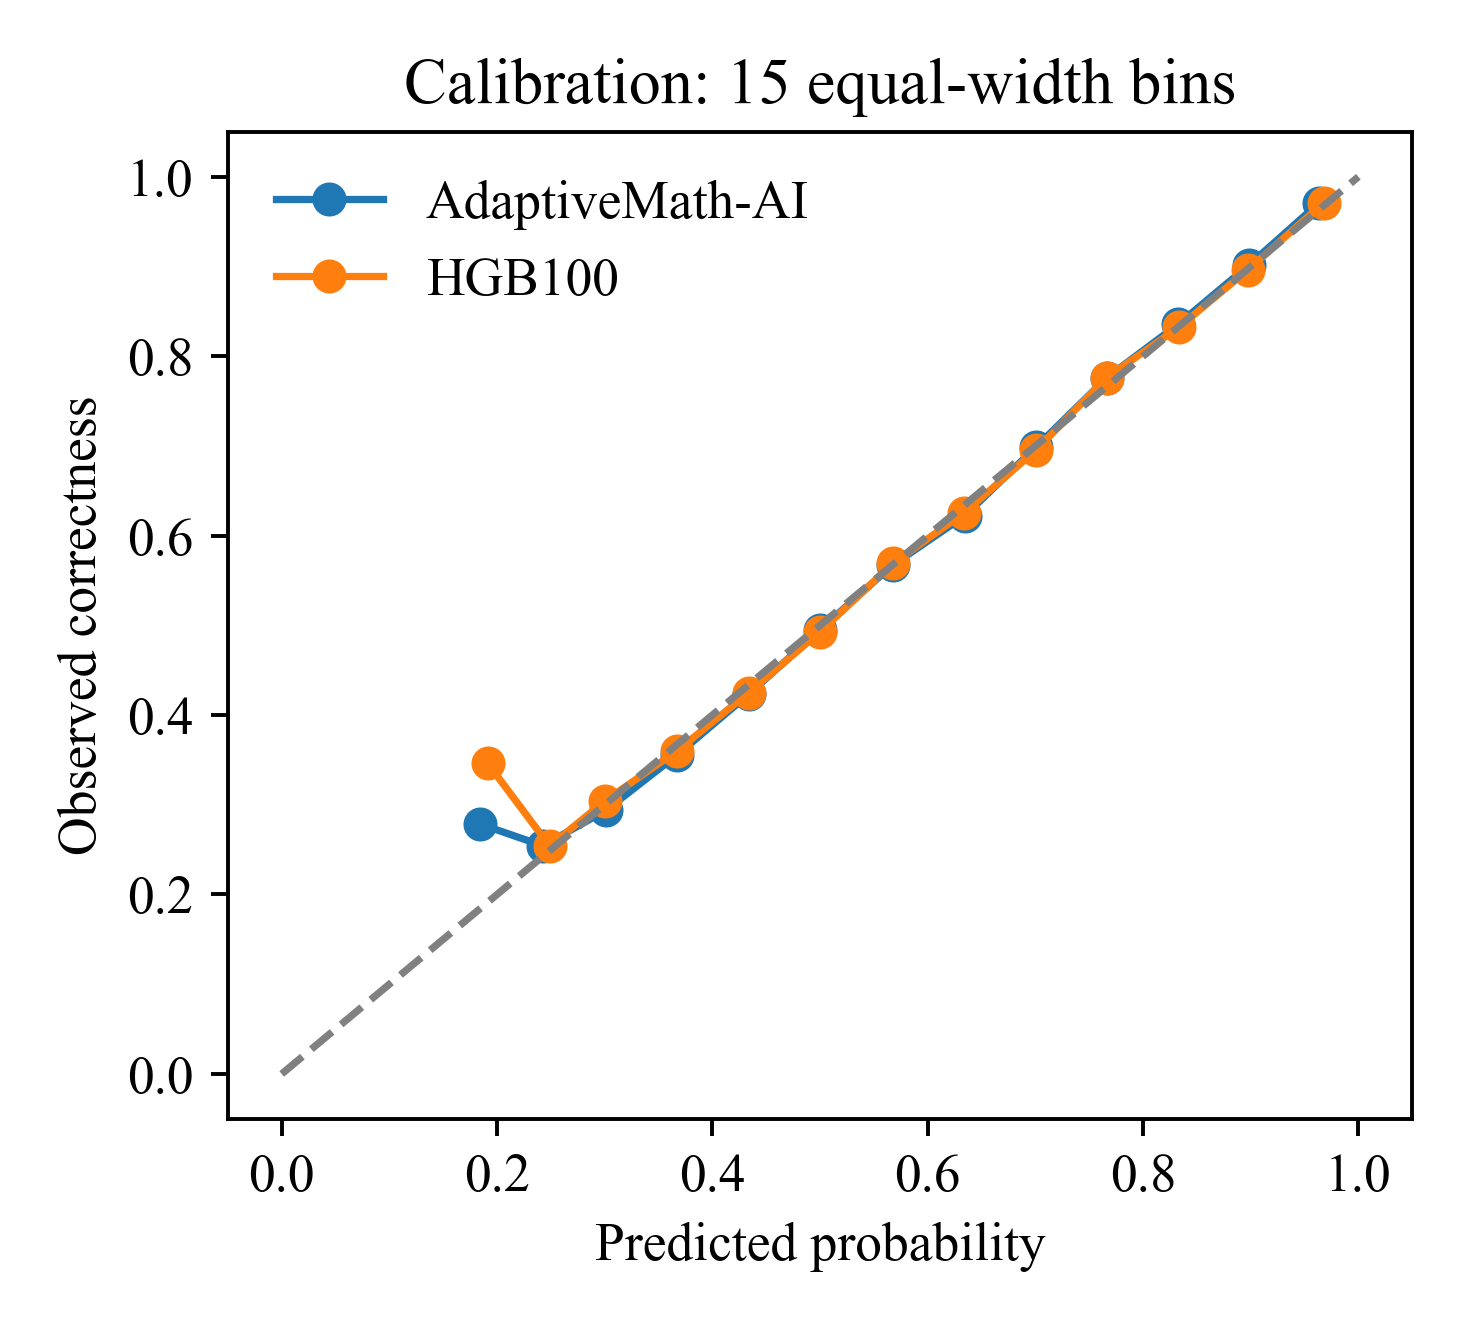

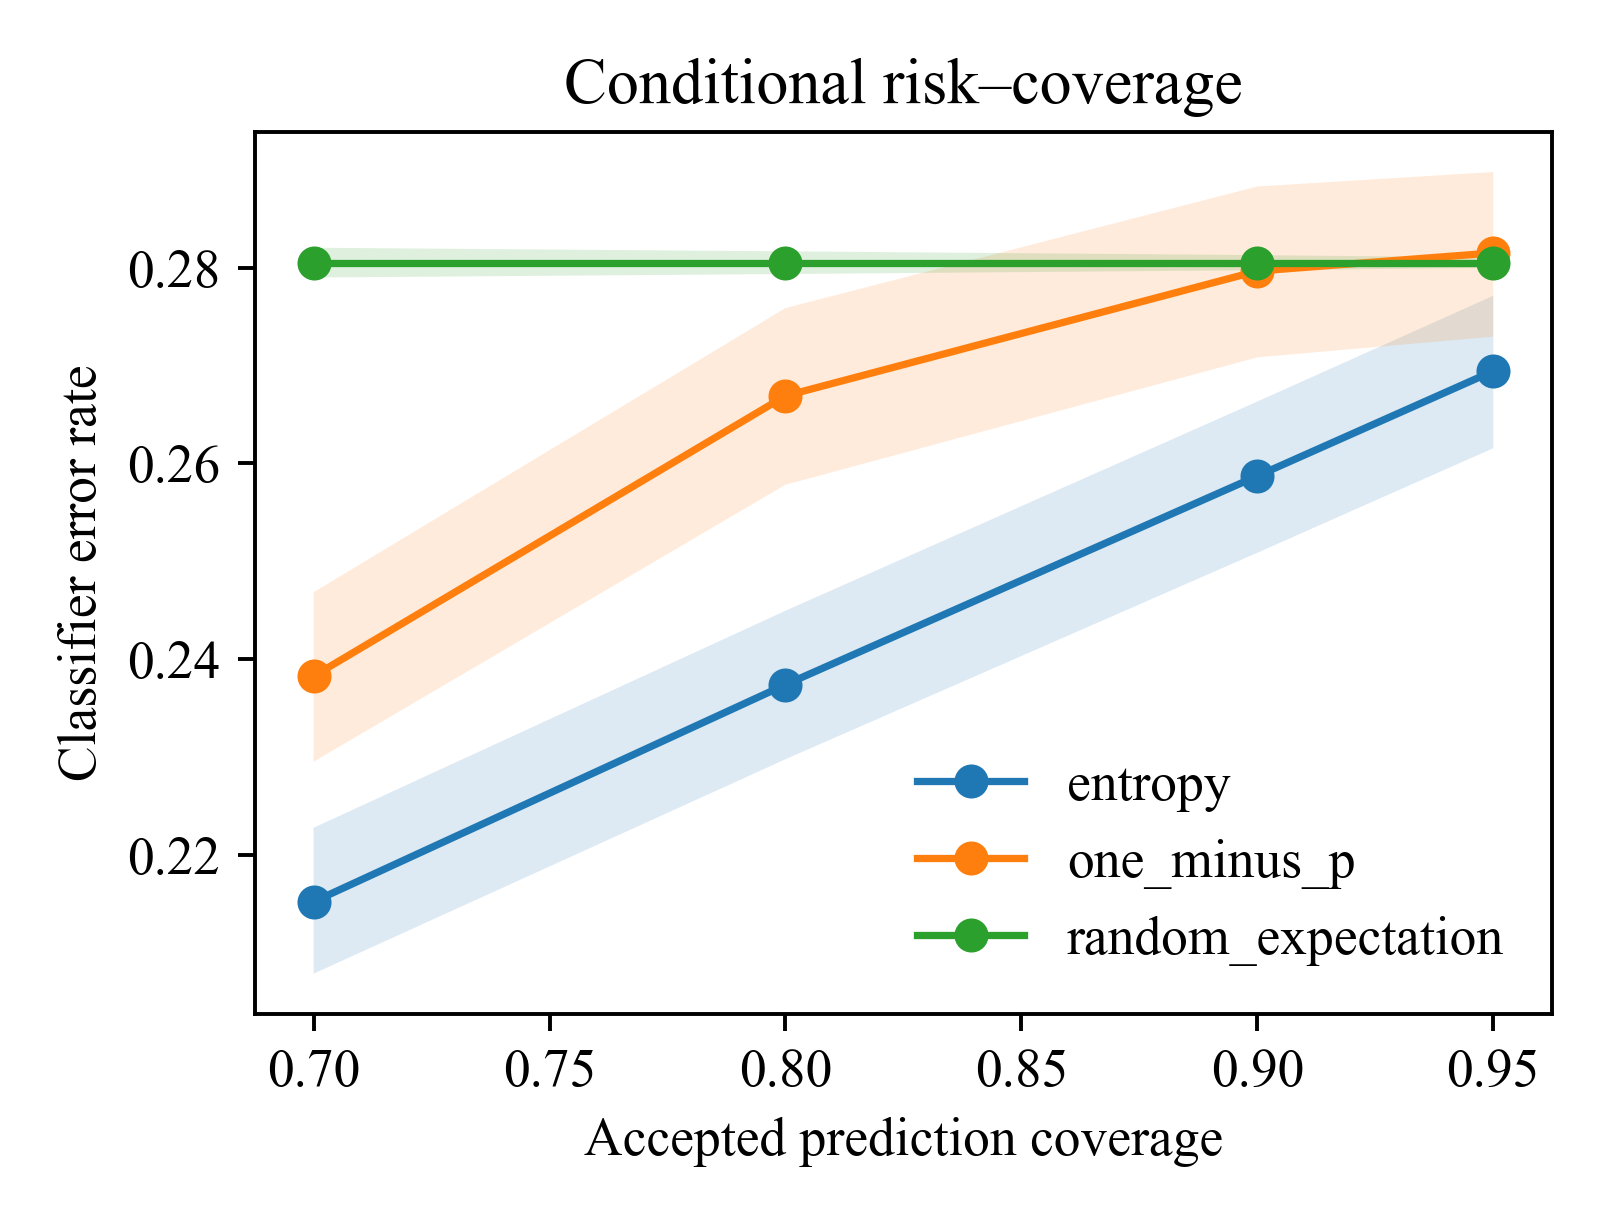

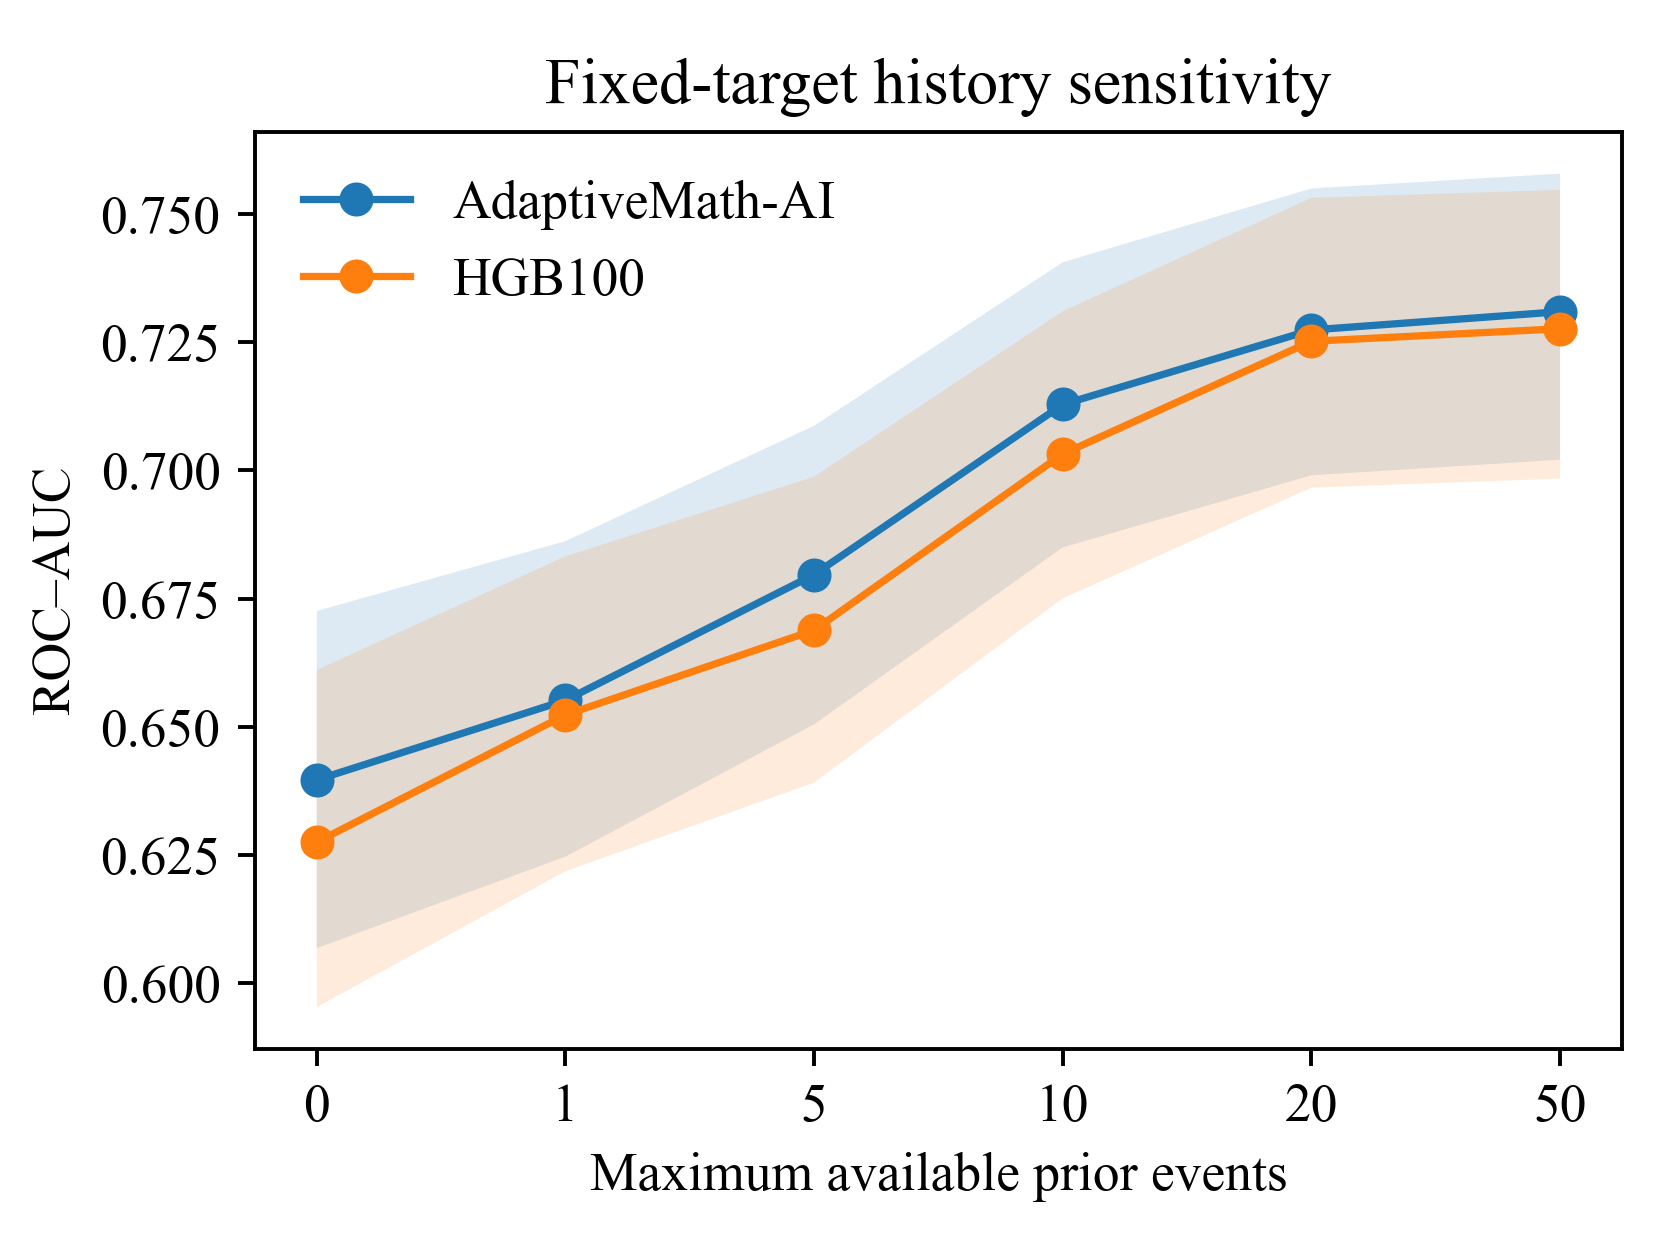

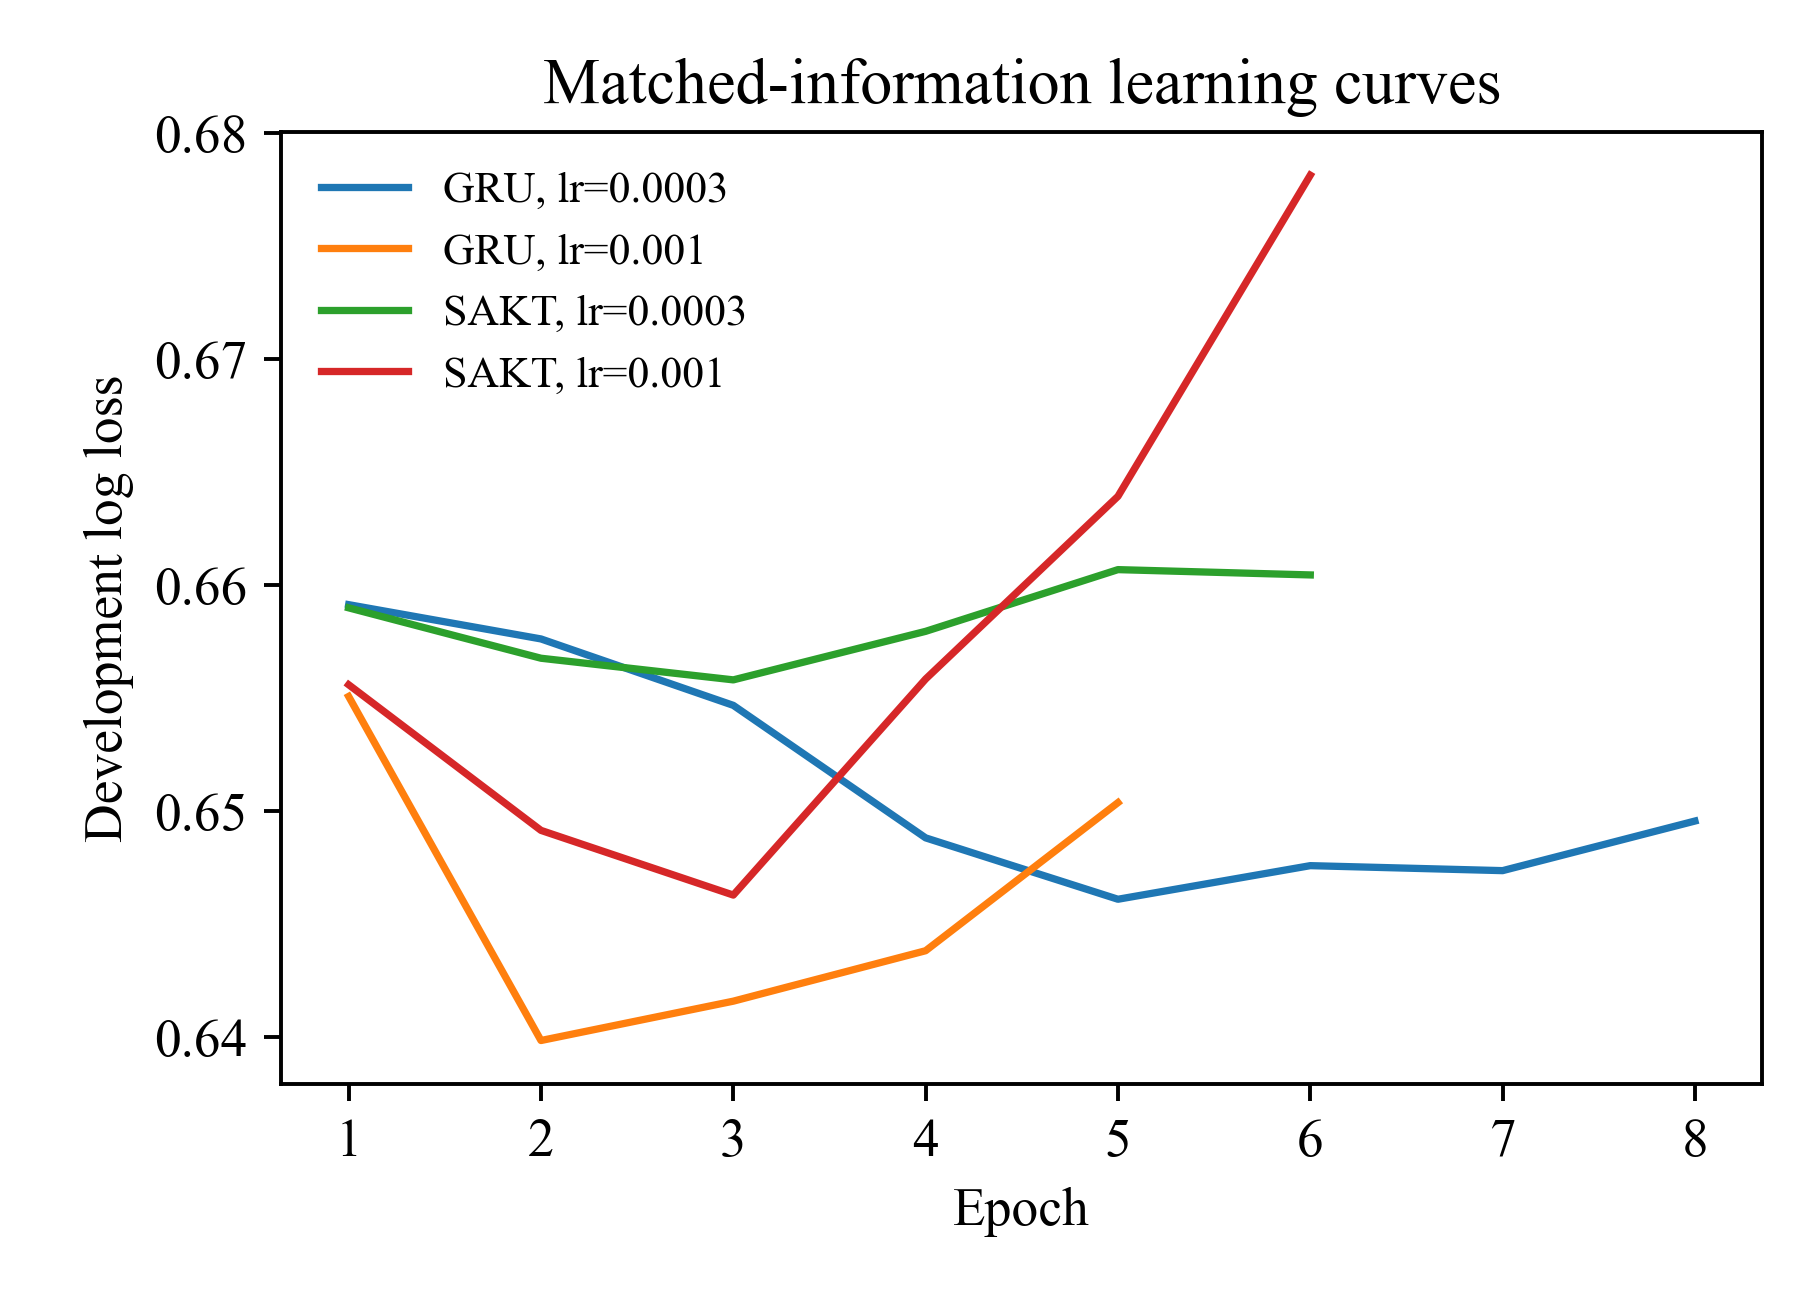

In [2]:
import revision_evaluation as re
re.diagnostic_figures()

In [9]:
from revision_closure import validate_artifacts
display(validate_artifacts())

,check,expected,observed,status
0,primary outer fits,50,50,PASS
1,paired primary bootstrap draws per cluster,5000,5000,PASS
2,neural candidate training runs,12,12,PASS
3,row prediction registry entries,all declared primary and secondary exports,1517,PASS
